# Reproducing Prospector's physics with tengri

Prospector (Johnson, Leja, Conroy & Speagle 2021) is the most widely used
Bayesian SED-fitting framework in extragalactic astronomy. Its forward
model is FSPS (Conroy, Gunn & White 2009), called through `python-fsps`.
This study configures tengri's public API to approximate Prospector's model choices; tengri's implementation is its own, not derived from Prospector's code, and residual differences are quantified below.

The left panel of each figure is FSPS evaluated live through `python-fsps`,
the engine Prospector uses; the right panel is tengri. Both read the same
SSP templates: tengri loads FSPS MIST + MILES Chabrier from the public
catalog, so a §1 residual below floating-point precision is interpolation
alone. The fiducial galaxy is a τ-delayed SFH (τ = 1 Gyr, age 5 Gyr) at
solar metallicity with Calzetti dust (A_V = 1) and DL07 IR re-emission at
(q_PAH, U_min, γ) = (2.5, 1.0, 0.05), and each section sweeps one physics
block around it.

The closed-form blocks and the shared SSP grid reproduce FSPS to floating
point or a fraction of a percent. The nebular block is the deliberate
exception: FSPS uses Byler+2017 Cloudy grids while tengri uses Cue (Li et
al. 2025), a neural emulator trained on a different Cloudy version, and §8
quantifies the Hα ratio difference. Prospector has no X-ray or radio
component; the CIGALE notebook covers that stack.

## Setup

In [1]:
import os

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")
# python-fsps needs SPS_HOME to find the FSPS tables; the driver also
# checks this and raises a friendly error if it is unset.
if not os.environ.get("SPS_HOME"):
    raise SystemExit(
        "SPS_HOME is not set. Point it at your FSPS checkout before running:\n"
        "    export SPS_HOME=/path/to/fsps\n"
        "See reproduction/prospector/README.md."
    )

import warnings
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np
from reproduction.prospector._drivers import prospector_driver as P, units as U

import tengri
from tengri import DEFAULT, Fixed, SEDModel, load_ssp_data
from tengri.utils.physics_constants import LOG10_ZSUN

# Force the inline backend so figures embed on (re-)render regardless of the
# ambient MPLBACKEND. A non-inline backend (e.g. Agg) drops the save_fig()
# auto-display and produces a figure-less notebook. No-op when run as a script.
try:  # noqa: SIM105
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

warnings.filterwarnings("ignore")
tengri.plot.setup_style()

# Unit-sanity guard: FSPS returns L_ν in L⊙/Hz, which the driver scales
# by FSPS' own L⊙ to reach erg/s/Hz. Every panel below claims
# percent-level agreement, so a factor bug in the converter would
# silently misshape the whole notebook. Assert the bolometric round-trip
# here — the notebook trips at Setup if the converter ever drifts.
_unit_check = U.verify_unit_conversion(rtol=1e-3)
print(
    f"unit-conversion bolometric round-trip: "
    f"rel_err = {_unit_check['rel_err']:.2e}  (target < 1e-3)"
)

# Metallicity pin. FSPS `logzsol` and tengri `logzsol` are both log10(Z / Z⊙),
# against the same Asplund+2009 Z⊙ that `LOG10_ZSUN` carries, so solar on both
# sides is logzsol = 0. A library whose Z⊙ differs (BC03/Padova, PARSEC, BASTI)
# breaks that identity — see LOG10_ZSUN_BY_LIBRARY.
MET_LOGZSOL = 0.0
MET_FIDUCIAL = {"logzsol": Fixed(MET_LOGZSOL), "all_params": Fixed(DEFAULT)}

# Fiducial galaxy shared across the SED panels.
LOG_MASS_FIDUCIAL = 10.0
TAU_GYR_FIDUCIAL = 1.0
AGE_GYR_FIDUCIAL = 5.0
AV_FIDUCIAL = 1.0
QPAH_FIDUCIAL = 2.5
UMIN_FIDUCIAL = 1.0
GAMMA_FIDUCIAL = 0.05
# FSPS spectra are per 1 M⊙ formed; tengri's log_total_mass sets an
# absolute formed mass. To compare absolute L_ν the FSPS side is scaled
# by MASS_SCALE so both panels show a 10^10 M⊙ galaxy.
MASS_SCALE = 10.0**LOG_MASS_FIDUCIAL

# nbclient kernels don't bind ``__file__`` (the kernel's resources path
# is the notebook directory instead), so fall back to the CWD.
_HERE = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd().resolve()
figs_dir = _HERE / "_figs"
figs_dir.mkdir(exist_ok=True)

_FIG_DPI = 150


def save_fig(filename: str) -> None:
    """Save figure to ``_figs/`` and leave it open so inline embeds work."""
    plt.savefig(str(figs_dir / filename), dpi=_FIG_DPI, bbox_inches="tight")


def _assert_comparable(arr_ref, arr_t, *, name: str) -> None:
    """Guard against shipping a blank or wildly mis-scaled panel."""
    a_ref = np.asarray(arr_ref)
    a_t = np.asarray(arr_t)
    assert np.isfinite(a_ref).any() and np.isfinite(a_t).any(), f"{name}: NaN-only"
    assert (a_ref > 0).any() and (a_t > 0).any(), f"{name}: zero/negative-only"
    ratio = a_ref.max() / a_t.max()
    assert 1e-3 < ratio < 1e3, f"{name}: y-scale ratio {ratio:.2e} out of range"

unit-conversion bolometric round-trip: rel_err = 3.11e-06  (target < 1e-3)


## Common SSP grid

The FSPS MIST + MILES Chabrier grid — the same templates the local FSPS
installation uses — fetched once from the public catalog and cached under
`_drivers/data/`.

In [2]:
ssp_path = tengri.download_ssp("fsps_mist_miles_chabrier", dest=str(_HERE / "_drivers" / "data"))
ssp = load_ssp_data(str(ssp_path))
print(
    f"FSPS MIST+MILES Chabrier SSP: {ssp.ssp_wave.shape[0]} wavelengths, "
    f"{ssp.ssp_lgmet.shape[0]} metallicities, "
    f"{ssp.ssp_lg_age_gyr.shape[0]} age bins; "
    f"λ up to {ssp.ssp_wave.max():.1e} Å."
)

SSP file already exists at /tengri/reproduction/prospector/_drivers/data/fsps_mist_miles_chabrier.h5; skipping download.


FSPS MIST+MILES Chabrier SSP: 5994 wavelengths, 12 metallicities, 107 age bins; λ up to 1.0e+08 Å.


## §1 Single stellar populations

FSPS MIST + MILES at solar metallicity, from 1 Myr to 10 Gyr, with the
relative residual `|tengri − FSPS| / FSPS` below. Both read identical
numerics; the residual floor is the float32 round-trip — gray line marks
1e-6.

**Verification Status:** CROSSVAL (2 tests — thin) — CSP integral — CIC age kernel (default)

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§1 SSP 1 Gyr optical residual: median 1.80e-09, max 3.74e-08


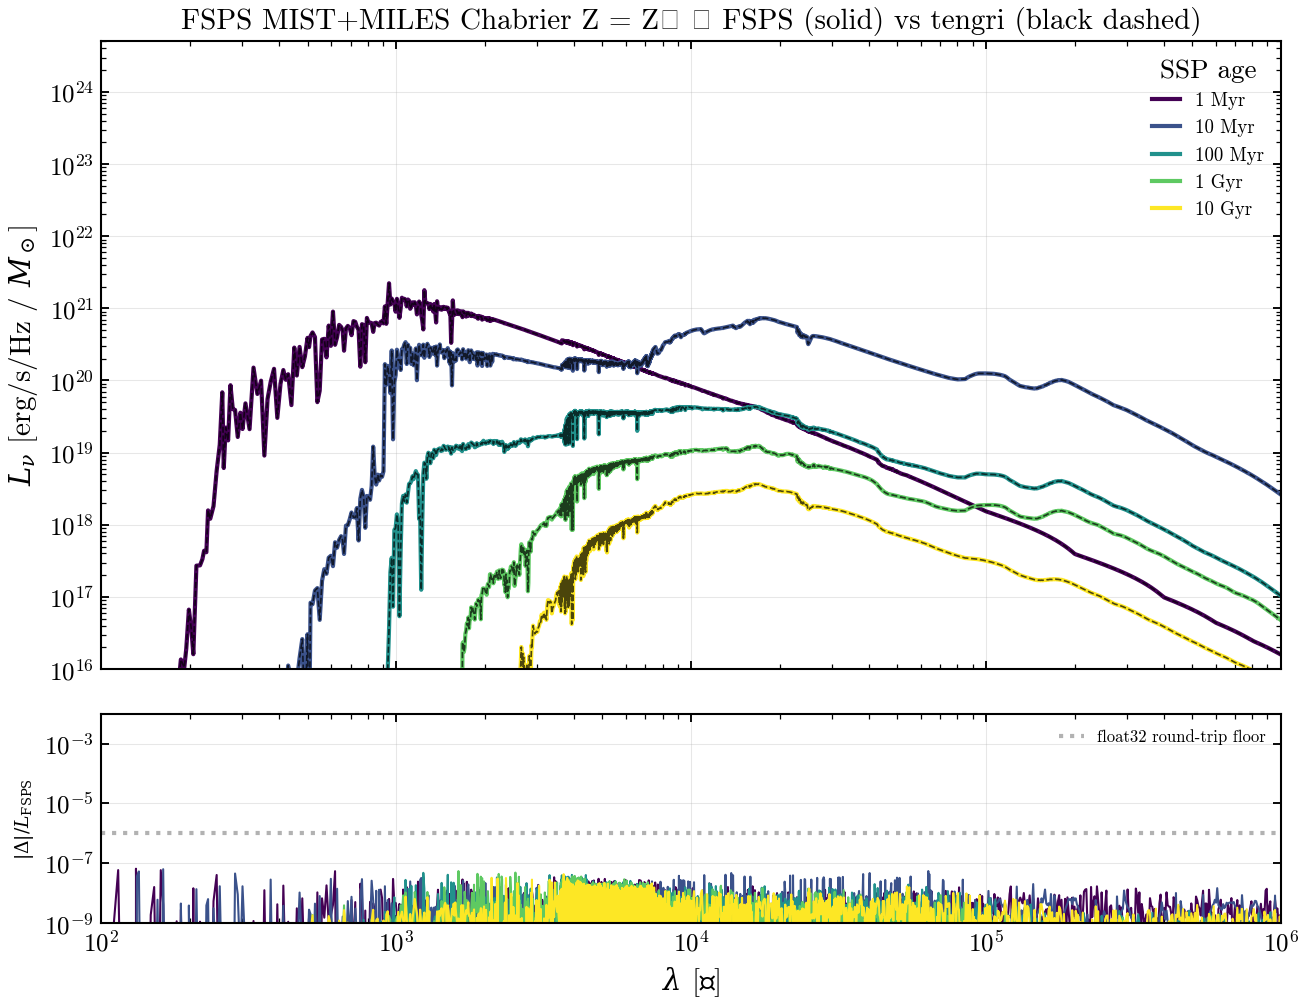

In [3]:
_target_ages_yr = [1e6, 1e7, 1e8, 1e9, 1e10]
i_zsun = int(np.argmin(np.abs(ssp.ssp_lgmet - LOG10_ZSUN)))
# Use grid-native ages so FSPS and the repackaged grid land on the same age
# samples (no age interpolation on either side).
_age_idx = [
    int(np.argmin(np.abs(ssp.ssp_lg_age_gyr - np.log10(a / 1e9)))) for a in _target_ages_yr
]

fps_ssp, tng_ssp, age_labels = [], [], []
for ia in _age_idx:
    age_gyr = float(10.0 ** ssp.ssp_lg_age_gyr[ia])
    w_p, L_p = P.ssp_spectrum(logzsol=0.0, age_gyr=age_gyr)
    fps_ssp.append((w_p, L_p))
    # tengri-side conversion uses tengri's own (IAU) L⊙: the loader rescales
    # the repackaged grid's FSPS-native Lsun units to IAU on load (#969), so
    # converting with the driver's FSPS constant would double-count 0.29 %.
    tng_ssp.append(
        (ssp.ssp_wave, np.asarray(tengri.units.lsun_to_erg_per_s(ssp.ssp_flux[i_zsun, ia, :])))
    )
    age_labels.append(f"{age_gyr * 1e3:g} Myr" if age_gyr < 1 else f"{age_gyr:g} Gyr")

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
colors = plt.cm.viridis(np.linspace(0, 1, len(_age_idx)))
for color, label, (w_p, L_p), (w_t, L_t) in zip(colors, age_labels, fps_ssp, tng_ssp):
    ax.plot(w_p, L_p, color=color, linewidth=2.0, label=label)
    ax.plot(w_t, L_t, color="k", linewidth=0.8, linestyle="--", alpha=0.7)
    L_t_on_p = U.regrid(w_t, L_t, w_p)
    resid = np.abs(L_t_on_p - L_p) / np.maximum(np.abs(L_p), 1e-30)
    resid[~np.isfinite(resid)] = 0.0
    ax_r.plot(w_p, resid, color=color, linewidth=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e6)
ax.set_ylim(1e16, 5e24)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz / $M_\odot$]")
ax.set_title("FSPS MIST+MILES Chabrier Z = Z⊙ — FSPS (solid) vs tengri (black dashed)")
ax.legend(fontsize=9, title="SSP age")
ax.grid(True, alpha=0.3)
ax_r.set_xscale("log")
ax_r.set_yscale("log")
ax_r.set_xlabel(r"$\lambda$ [Å]")
ax_r.set_ylabel(r"$|\Delta| / L_{\rm FSPS}$", fontsize=9)
ax_r.set_ylim(1e-9, 1e-2)
ax_r.axhline(1e-6, color="gray", linestyle=":", alpha=0.6, label="float32 round-trip floor")
ax_r.legend(loc="upper right", fontsize=8)
ax_r.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_01_ssp_fsps.png")

# Median residual in the optical, a useful scalar for the docs page.
_w_ref, _L_ref = fps_ssp[3]  # 1 Gyr
_mask = (_w_ref >= 3000) & (_w_ref <= 10000)
_t_on_p = U.regrid(tng_ssp[3][0], tng_ssp[3][1], _w_ref)
_res = np.abs(_t_on_p[_mask] - _L_ref[_mask]) / np.maximum(_L_ref[_mask], 1e-30)
print(f"§1 SSP 1 Gyr optical residual: median {np.median(_res):.2e}, max {_res.max():.2e}")

## §2 Star formation history — delayed-τ

FSPS `sfh=4` uses the delayed-exponential `SFR(t) ∝ t · exp(−t/τ)`, peaking
at `t = τ`. tengri's `sfh.delayed` implements the same closed form. Both
normalize to the same formed mass: FSPS via `mass`, tengri via `log_total_mass`.

The right panel evaluates `state.derived["sfr_history"]` from a built
`SEDModel` on the log-spaced lookback grid the SFH-convolution code uses. The
printed `∫SFR dt` confirms the area integrates to 1 M⊙ (tengri `log_total_mass = 0`).

**Verification Status:** PARTIAL (11/33) — Parametric SFH family physics

§2 ∫SFR dt: FSPS = 1.0000 M⊙, tengri pipeline = 1.0000 M⊙ (target 1.0000)


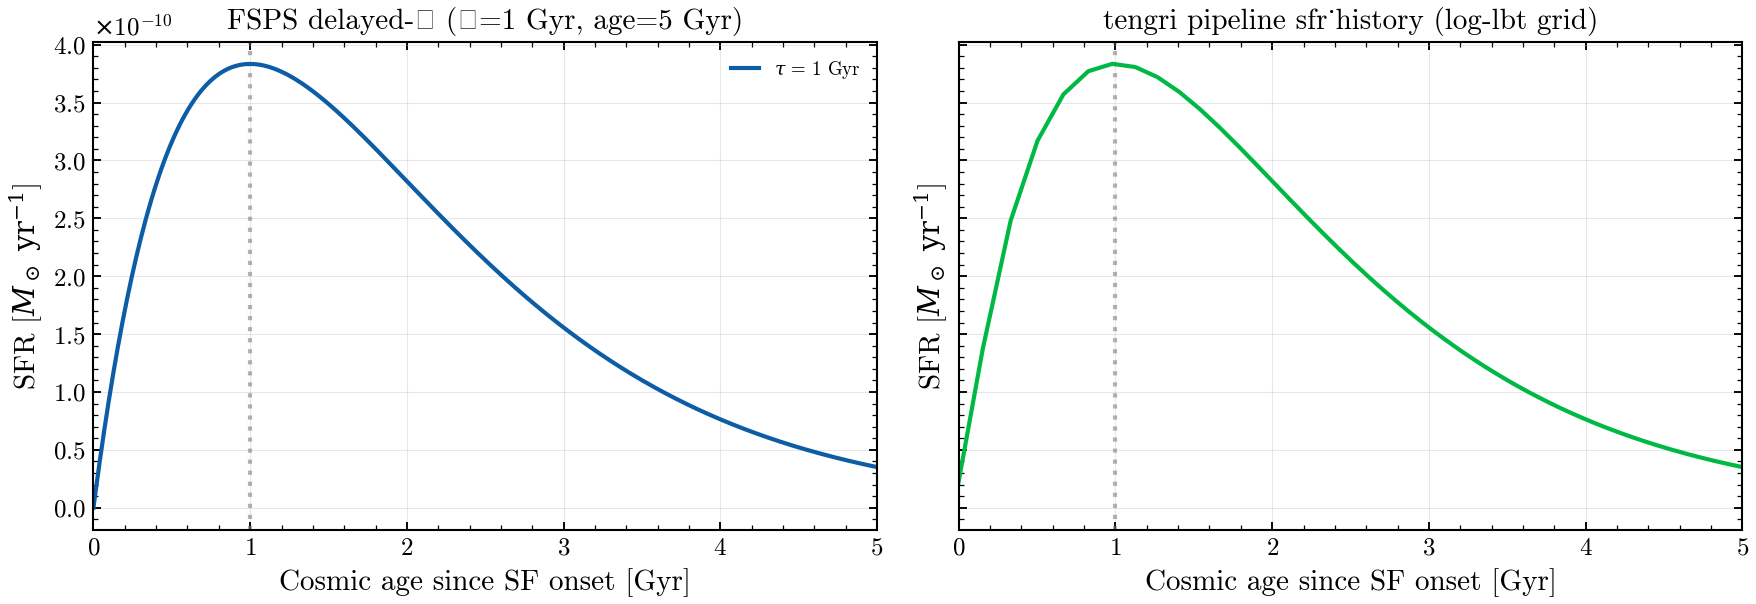

In [4]:
t_p, sfr_p = P.sfh_curve(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL)
t_p_cosmic_gyr = AGE_GYR_FIDUCIAL - t_p / 1e9
_mass_p = float(np.trapezoid(sfr_p[np.argsort(t_p)], t_p[np.argsort(t_p)]))

_m_sfh = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
_state_sfh = _m_sfh.predict_state({})
_lbt_yr = np.asarray(_state_sfh.derived["sfh_grid_lbt_yr"])
_sfr_history = np.asarray(_state_sfh.derived["sfr_history"])
t_t_cosmic_gyr = AGE_GYR_FIDUCIAL - _lbt_yr / 1e9
_idx = np.argsort(_lbt_yr)
_mass_t = float(np.trapezoid(_sfr_history[_idx], _lbt_yr[_idx]))
print(f"§2 ∫SFR dt: FSPS = {_mass_p:.4f} M⊙, tengri pipeline = {_mass_t:.4f} M⊙ (target 1.0000)")

fig, ax_l, ax_r = U.two_panel_fig()
for ax, title in (
    (ax_l, "FSPS delayed-τ (τ=1 Gyr, age=5 Gyr)"),
    (ax_r, "tengri pipeline sfr_history (log-lbt grid)"),
):
    ax.set_xlabel("Cosmic age since SF onset [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot\ \mathrm{yr}^{-1}$]")
    ax.set_xlim(0, 5)
    ax.set_yscale("linear")
    ax.set_xscale("linear")
    ax.grid(True, alpha=0.3)
    ax.set_title(title)
    ax.axvline(TAU_GYR_FIDUCIAL, color="gray", linestyle=":", alpha=0.6)
ax_l.plot(t_p_cosmic_gyr, sfr_p, "C0-", linewidth=2.0, label=rf"$\tau$ = {TAU_GYR_FIDUCIAL:g} Gyr")
ax_l.legend(fontsize=9)
ax_r.plot(t_t_cosmic_gyr, _sfr_history, "C1-", linewidth=2.0)
fig.tight_layout()
save_fig("prospector_02_sfh_delayed.png")

## §2′ Non-parametric star formation histories

Prospector's non-parametric SFR in lookback bins (amplitudes free, lowered
through `prospect.models.transforms` to FSPS `sfh=3`). tengri implements the
same families as analytic step functions convolved with SSPs. Each panel uses
the shared seven-bin grid `[0, 0.03, 0.1, 0.3, 1, 3, 6, 13.7] Gyr`. Both
codes order log-SFR ratios youngest-first with the same sign, so the same
numbers drive both.

Remaining 0.3–2% optical residuals trace to comparison conventions: tengri's
age weights match dense code-independent quadrature of the same SSP arrays
to ~1e-4 per node; Prospector floors the youngest bin at 1 Myr where
tengri fills to lookback 0; and FSPS's `sfh=3` path carries its own
quadrature. The L⊙ constant mismatch is rescaled at SSP load.

In [5]:
# Shared seven-bin lookback grid (tengri's DEFAULT_BIN_EDGES_GYR). Passed
# explicitly to both sides so FSPS and tengri bin the history identically.
NONPARAM_EDGES_GYR = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 6.0, 13.7])
AGE_UNIV_GYR = float(NONPARAM_EDGES_GYR[-1])  # observation epoch (z = 0)


def _step_sfr(agebins, masses):
    """Step-function SFR [M⊙/yr] per bin and the cosmic-age edges for plotting."""
    edges_yr = np.concatenate([10.0 ** agebins[:, 0], [10.0 ** agebins[-1, 1]]])
    sfr_bins = np.asarray(masses) / np.diff(edges_yr)
    cosmic_edges = AGE_UNIV_GYR - edges_yr / 1e9  # lookback → cosmic age [Gyr]
    return sfr_bins, cosmic_edges


def _plot_step(ax, agebins, masses, color, label):
    """Draw a piecewise-constant SFR(cosmic age) from (agebins, masses)."""
    sfr_bins, cosmic_edges = _step_sfr(agebins, masses)
    for i in range(sfr_bins.shape[0]):
        ax.plot(
            [cosmic_edges[i + 1], cosmic_edges[i]],
            [sfr_bins[i], sfr_bins[i]],
            color=color,
            linewidth=2.0,
            label=label if i == 0 else None,
        )


def _tengri_nonparam(sfh_dict, params=None):
    """Build a dust-free tengri model from an SFH dict and return its state."""
    model = SEDModel.build(
        ssp_data=ssp,
        met=MET_FIDUCIAL,
        sfh=sfh_dict,
        dust_attenuation={
            "law": "power_law",
            "type": "two_component",
            "tau_bc": Fixed(0.0),
            "tau_diff": Fixed(0.0),
            "all_params": Fixed(DEFAULT),
        },
        redshift=Fixed(0.0),
    )
    return model, model.predict_state(params if params is not None else {})


def _optical_resid(w_ref, L_ref, w_t, L_t):
    """Median |Δ|/L over 3000–10000 Å, after regridding tengri onto FSPS."""
    L_t_on = U.regrid(np.asarray(w_t), np.asarray(L_t), np.asarray(w_ref))
    m = (w_ref >= 3000) & (w_ref <= 10000) & (L_ref > 0)
    return float(np.median(np.abs(L_t_on[m] - L_ref[m]) / L_ref[m]))


def _sfr_sed_fig(title_sfr):
    """Two-panel figure: SFR(cosmic age) on the left, stellar L_ν on the right.

    Independent y-axes — unlike ``U.two_panel_fig`` (``sharey=True`` for two
    SED panels) — because SFR [M⊙/yr] and L_ν [erg/s/Hz] occupy entirely
    different ranges and must not share a y-scale.
    """
    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax_l.set_yscale("linear")  # SFH shape reads best on a linear SFR axis
    ax_l.set_xlabel("Cosmic age [Gyr]")
    ax_l.set_ylabel(r"SFR [$M_\odot\ \mathrm{yr}^{-1}$]")
    ax_l.set_xlim(0, AGE_UNIV_GYR)
    # NB: don't pin the y-range before plotting — that freezes the top and
    # disables autoscale, clipping tall bursts. Each section anchors at 0 via
    # _anchor_sfr_axis() after its curves are drawn.
    ax_l.set_title(title_sfr)
    ax_l.grid(True, alpha=0.3)
    ax_r.set_xscale("log")
    ax_r.set_yscale("log")
    ax_r.set_xlim(1e3, 2e4)
    ax_r.set_xlabel(r"$\lambda_{\rm rest}$ [Å]")
    ax_r.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
    ax_r.set_title("Stellar SED")
    ax_r.grid(True, alpha=0.3)
    return fig, ax_l, ax_r


def _anchor_sfr_axis(ax):
    """Anchor the SFR axis at 0 while keeping the autoscaled top (no clipping)."""
    ax.set_ylim(0.0, ax.get_ylim()[1])


def _tighten_sed_axis(ax, *wave_lnu_pairs):
    """Clamp the SED y-range to the data inside the visible 1000–20000 Å window.

    Autoscaling otherwise keys on the full spectrum — including the far-UV and
    far-IR outside the plotted x-window, where L_ν is orders of magnitude lower
    — squashing the optical/NIR SED into a thin strip at the top of the panel.
    """
    lo, hi = ax.get_xlim()
    ymax = 0.0
    for wave, lnu in wave_lnu_pairs:
        w = np.asarray(wave)
        lv = np.asarray(lnu)
        m = (w >= lo) & (w <= hi) & np.isfinite(lv) & (lv > 0)
        if m.any():
            ymax = max(ymax, float(lv[m].max()))
    if ymax > 0:
        ax.set_ylim(ymax / 50.0, ymax * 2.0)

### §2a Continuity (Leja+2019)

The workhorse non-parametric SFH: a Student-t prior on the log-SFR ratios
between adjacent bins enforces a smooth, continuous history while still
admitting bursts. Here a gently rising history. Prospector's
`logsfr_ratios_to_masses` and tengri's `continuity` consume the identical
ratio array.

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§2a continuity: optical median residual 5.74e-03


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


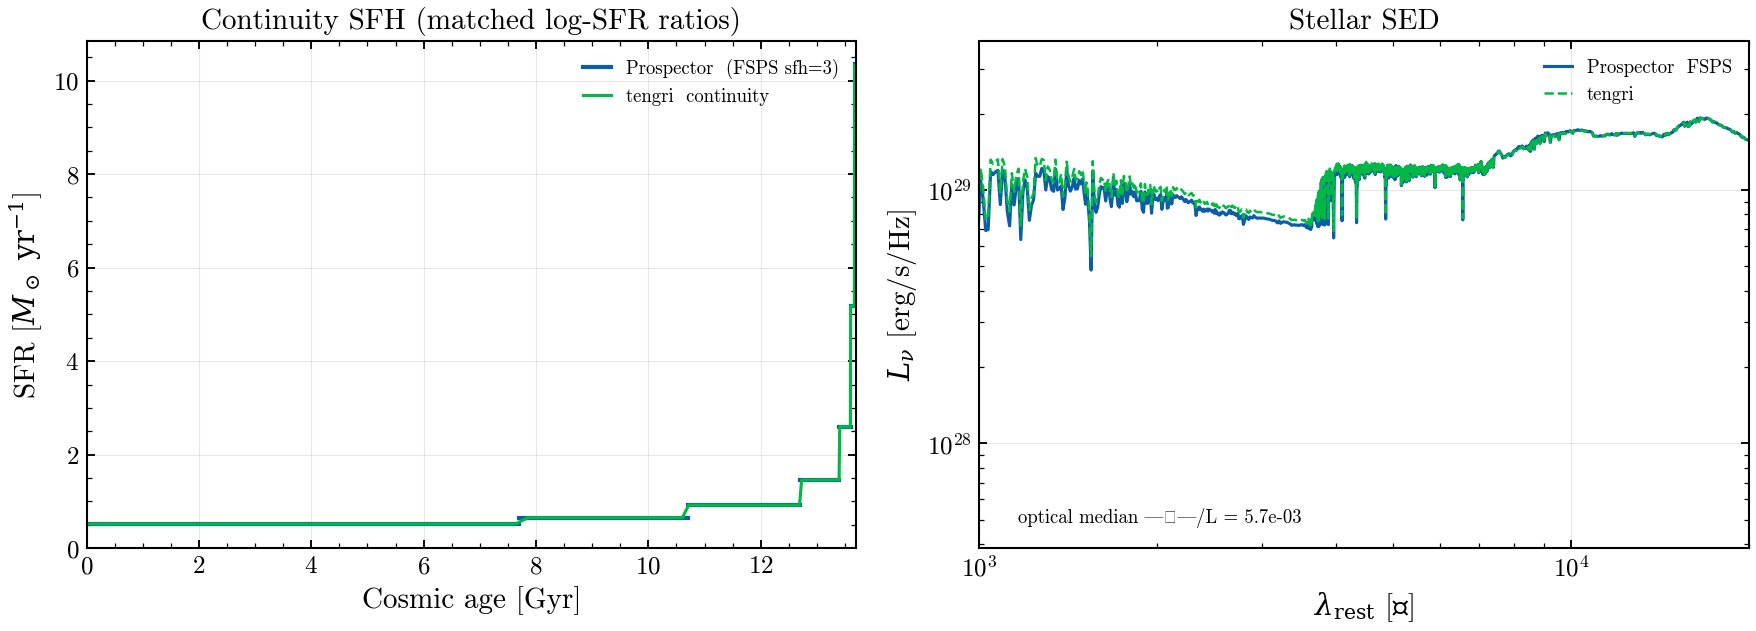

In [6]:
CONT_RATIOS = np.array([0.3, 0.3, 0.25, 0.2, 0.15, 0.1])  # log10(SFR_j / SFR_{j+1})

ab_cont, m_cont = P.continuity_masses(
    bin_edges_gyr=NONPARAM_EDGES_GYR, log_total_mass=LOG_MASS_FIDUCIAL, logsfr_ratios=CONT_RATIOS
)
w_cont, L_cont = P.csp_lnu_binned(agebins=ab_cont, masses=m_cont, logzsol=MET_LOGZSOL)

_sfh_cont = {
    "type": "continuity",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "all_params": Fixed(DEFAULT),
}
_sfh_cont.update({f"ratio_{i}": Fixed(float(r)) for i, r in enumerate(CONT_RATIOS)})
_m_cont, _s_cont = _tengri_nonparam(_sfh_cont)
_assert_comparable(L_cont, _s_cont.sed_intrinsic, name="§2a continuity")

_lbt_c = np.asarray(_s_cont.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_c = np.asarray(_s_cont.derived["sfr_history"])
_res_c = _optical_resid(w_cont, L_cont, _s_cont.wave, _s_cont.sed_intrinsic)
print(f"§2a continuity: optical median residual {_res_c:.2e}")

fig, ax_l, ax_r = _sfr_sed_fig("Continuity SFH (matched log-SFR ratios)")
_plot_step(ax_l, ab_cont, m_cont, "C0", "Prospector  (FSPS sfh=3)")
ax_l.plot(AGE_UNIV_GYR - _lbt_c, _sfr_c, "C1-", linewidth=1.5, label="tengri  continuity")
ax_l.legend(fontsize=9)
ax_r.plot(w_cont, L_cont, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_cont.wave, _s_cont.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_c:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_cont, L_cont), (_s_cont.wave, _s_cont.sed_intrinsic))
save_fig("prospector_02a_sfh_continuity.png")

### §2b Continuity-flex (Leja+2019)

Continuity with *flexible* bin edges: the inner bin widths are themselves
derived from the log-SFR ratios under a constant-mass-per-flex-bin
constraint, with the youngest and oldest bins anchored. Prospector's
`logsfr_ratios_to_masses_flex` derives the bins; tengri's `continuity_flex`
reproduces the same Leja+2019 construction. Anchors
`[0.0316, 5.012, 13.7] Gyr`, three flex bins.

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§2b continuity_flex: optical median residual 1.51e-02


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


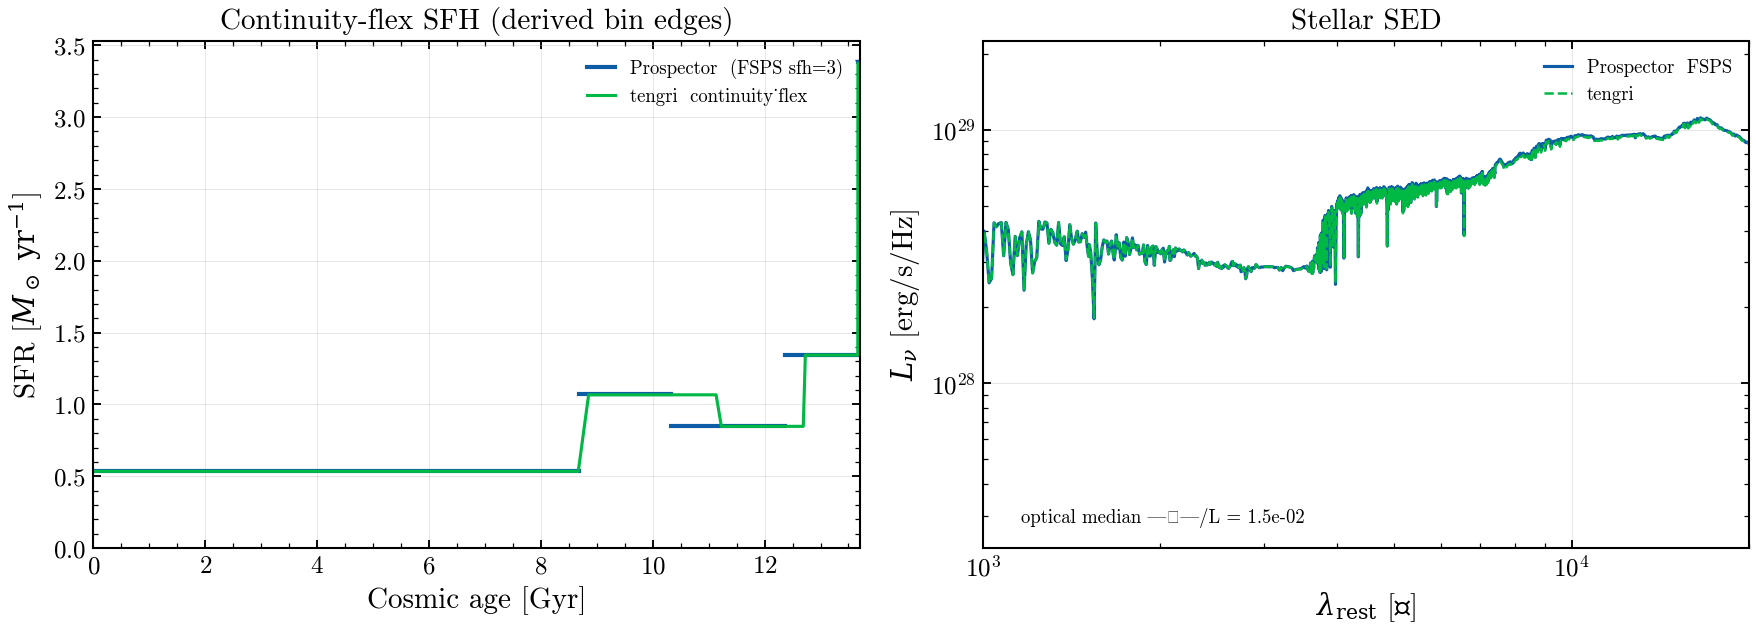

In [7]:
FLEX_ANCHORS_GYR = np.array([0.0316, 5.012, 13.7])
FLEX_RATIO_YOUNG = 0.4
FLEX_INNER = np.array([0.2, -0.1])  # 2 inner ratios → 3 flex bins
FLEX_RATIO_OLD = -0.3

ab_flex, m_flex = P.flex_masses(
    anchor_edges_gyr=FLEX_ANCHORS_GYR,
    log_total_mass=LOG_MASS_FIDUCIAL,
    logsfr_ratio_young=FLEX_RATIO_YOUNG,
    logsfr_ratios=FLEX_INNER,
    logsfr_ratio_old=FLEX_RATIO_OLD,
)
w_flex, L_flex = P.csp_lnu_binned(agebins=ab_flex, masses=m_flex, logzsol=MET_LOGZSOL)

_sfh_flex = {
    "type": "continuity_flex",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "ratio_young": Fixed(FLEX_RATIO_YOUNG),
    "ratio_old": Fixed(FLEX_RATIO_OLD),
    "flex_0": Fixed(float(FLEX_INNER[0])),
    "flex_1": Fixed(float(FLEX_INNER[1])),
    "all_params": Fixed(DEFAULT),
}
_m_flex, _s_flex = _tengri_nonparam(_sfh_flex)
_assert_comparable(L_flex, _s_flex.sed_intrinsic, name="§2b continuity_flex")

_lbt_f = np.asarray(_s_flex.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_f = np.asarray(_s_flex.derived["sfr_history"])
_res_f = _optical_resid(w_flex, L_flex, _s_flex.wave, _s_flex.sed_intrinsic)
print(f"§2b continuity_flex: optical median residual {_res_f:.2e}")

fig, ax_l, ax_r = _sfr_sed_fig("Continuity-flex SFH (derived bin edges)")
_plot_step(ax_l, ab_flex, m_flex, "C0", "Prospector  (FSPS sfh=3)")
ax_l.plot(AGE_UNIV_GYR - _lbt_f, _sfr_f, "C1-", linewidth=1.5, label="tengri  continuity_flex")
ax_l.legend(fontsize=9)
ax_r.plot(w_flex, L_flex, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_flex.wave, _s_flex.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_f:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_flex, L_flex), (_s_flex.wave, _s_flex.sed_intrinsic))
save_fig("prospector_02b_sfh_continuity_flex.png")

### §2c Dirichlet (Leja+2017)

The Dirichlet SFH places a symmetric prior on the fraction of star formation
in each bin. We lead with **Prospector's** parametrization — the one users
know — latent z-fractions → SFR fractions → bin masses
(`zfrac_to_masses`). tengri implements the same Leja+2017 family but with a
different latent variable (a stick-breaking prior on the *mass* fractions),
so the two codes' z-values are **not** interchangeable. To compare at a
matched, recognizably-Prospector SFH, we draw the history from Prospector's
transform and invert tengri's stick-breaking to the z that reproduces those
same bin masses. Both codes then evaluate the identical step SFH.

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§2c dirichlet: optical median residual 1.08e-02


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


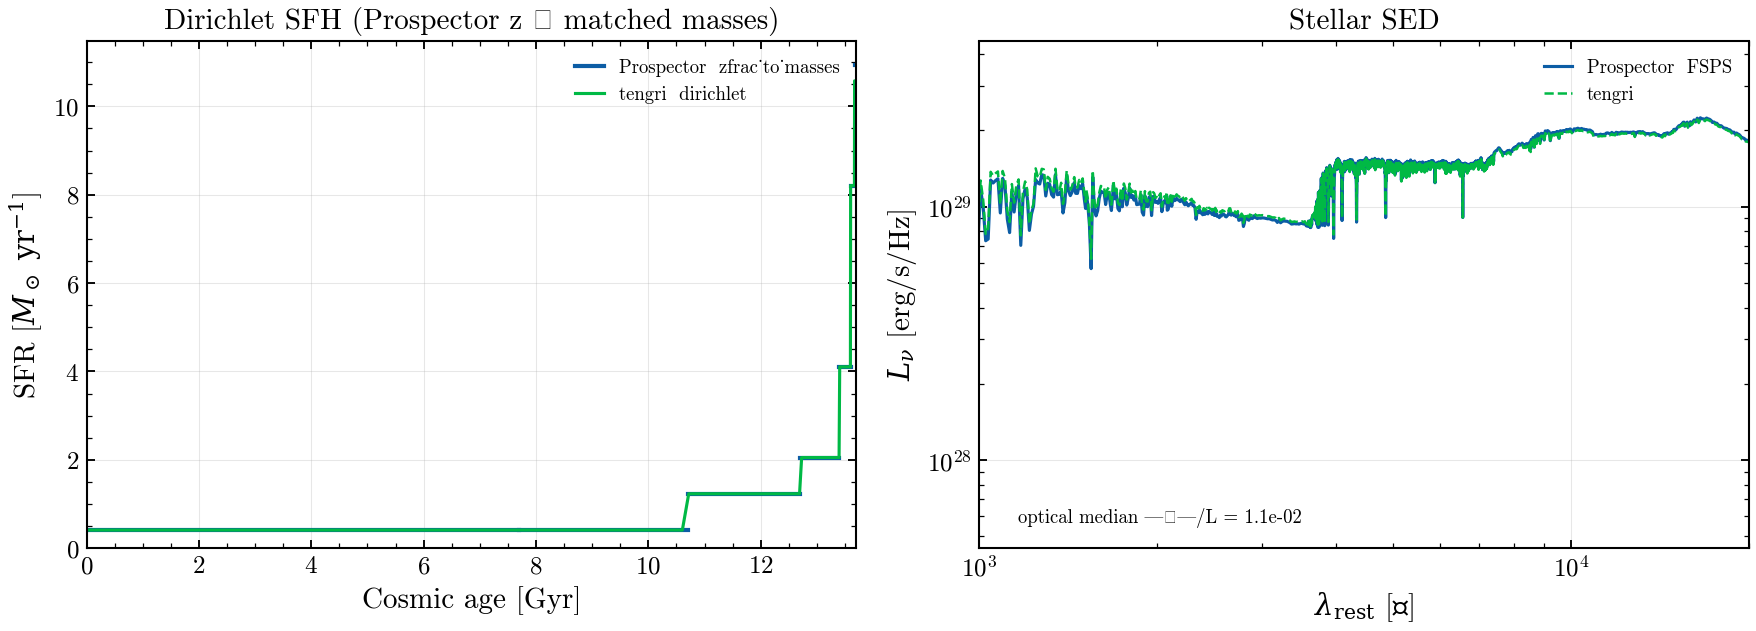

In [8]:
DIR_ZFRAC = np.array([0.6, 0.5, 0.5, 0.5, 0.4, 0.5])  # Prospector latent z-fractions

ab_dir, m_dir = P.dirichlet_masses(
    bin_edges_gyr=NONPARAM_EDGES_GYR, log_total_mass=LOG_MASS_FIDUCIAL, z_fraction=DIR_ZFRAC
)
w_dir, L_dir = P.csp_lnu_binned(agebins=ab_dir, masses=m_dir, logzsol=MET_LOGZSOL)


def _tengri_z_from_massfracs(mass_fracs):
    """Invert tengri's stick-breaking: mass fractions → latent z (youngest first)."""
    z = np.zeros(mass_fracs.shape[0] - 1)
    remaining = 1.0
    for i in range(z.shape[0]):
        z[i] = np.clip(mass_fracs[i] / remaining, 1e-6, 1.0 - 1e-6)
        remaining *= 1.0 - z[i]
    return z


_z_tengri = _tengri_z_from_massfracs(m_dir / m_dir.sum())
_sfh_dir = {
    "type": "dirichlet",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "all_params": Fixed(DEFAULT),
}
_sfh_dir.update({f"z_{i}": Fixed(float(z)) for i, z in enumerate(_z_tengri)})
_m_dir, _s_dir = _tengri_nonparam(_sfh_dir)
_assert_comparable(L_dir, _s_dir.sed_intrinsic, name="§2c dirichlet")

_lbt_d = np.asarray(_s_dir.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_d = np.asarray(_s_dir.derived["sfr_history"])
_res_d = _optical_resid(w_dir, L_dir, _s_dir.wave, _s_dir.sed_intrinsic)
print(f"§2c dirichlet: optical median residual {_res_d:.2e}")

fig, ax_l, ax_r = _sfr_sed_fig("Dirichlet SFH (Prospector z → matched masses)")
_plot_step(ax_l, ab_dir, m_dir, "C0", "Prospector  zfrac_to_masses")
ax_l.plot(AGE_UNIV_GYR - _lbt_d, _sfr_d, "C1-", linewidth=1.5, label="tengri  dirichlet")
ax_l.legend(fontsize=9)
ax_r.plot(w_dir, L_dir, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_dir.wave, _s_dir.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_d:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_dir, L_dir), (_s_dir.wave, _s_dir.sed_intrinsic))
save_fig("prospector_02c_sfh_dirichlet.png")

### §2d Post-starburst

A post-starburst (PSB) galaxy is the regime that motivated Prospector's
dedicated PSB template (Suess+2022, `logsfr_ratios_to_masses_psb`): a young
bin `[0, t_last]`, equal-mass flex bins to `t_flex`, and fixed old bins.
tengri implements the same family as `psb_suess2022` and forward-models it
through DSPS.

The cleanest *matched-parameter* head-to-head against FSPS uses the shared
**continuity** basis — a sharp negative youngest log-SFR ratio is a recent
shutdown, and both codes forward-model the continuity SFH exactly. Overlaid
on it is tengri's dedicated `psb_suess2022` template at matched
`t_last`/`t_flex`, the parametric PSB shape the family encodes directly.

§2d post-starburst: optical median residual 1.30e-03


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


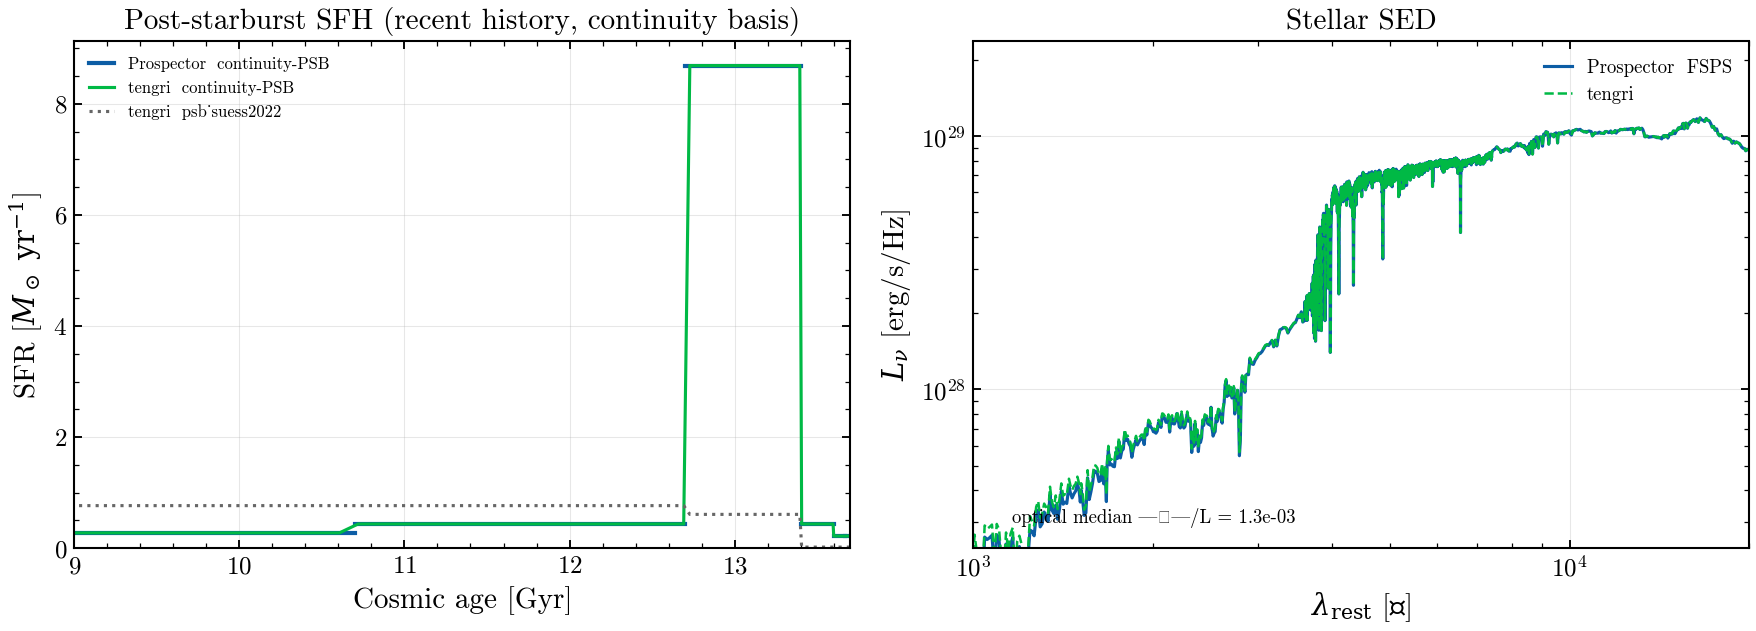

In [9]:
# Post-starburst as continuity ratios: a burst in the 0.3–1 Gyr bin followed by
# a sharp quench in the most recent bins. ratios[j] = log10(SFR_j / SFR_{j+1}),
# j=0 youngest. ratio_2 = -1.3 drops the recent bins well below the burst bin;
# ratio_3 = +1.3 raises the burst bin above the older baseline.
PSB_RATIOS = np.array([0.0, -0.3, -1.3, 1.3, 0.2, 0.0])

ab_psb, m_psb = P.continuity_masses(
    bin_edges_gyr=NONPARAM_EDGES_GYR, log_total_mass=LOG_MASS_FIDUCIAL, logsfr_ratios=PSB_RATIOS
)
w_psb, L_psb = P.csp_lnu_binned(agebins=ab_psb, masses=m_psb, logzsol=MET_LOGZSOL)

_sfh_psb = {
    "type": "continuity",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "all_params": Fixed(DEFAULT),
}
_sfh_psb.update({f"ratio_{i}": Fixed(float(r)) for i, r in enumerate(PSB_RATIOS)})
_m_psb, _s_psb = _tengri_nonparam(_sfh_psb)
_assert_comparable(L_psb, _s_psb.sed_intrinsic, name="§2d psb")

_lbt_p = np.asarray(_s_psb.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_p2 = np.asarray(_s_psb.derived["sfr_history"])
_res_p = _optical_resid(w_psb, L_psb, _s_psb.wave, _s_psb.sed_intrinsic)
print(f"§2d post-starburst: optical median residual {_res_p:.2e}")

# tengri's dedicated Suess+2022 PSB template (now wired into the DSPS forward
# pass): youngest bin [0, t_last], one flex bin to t_flex, then fixed old bins.
_sfh_suess = {
    "type": "psb_suess2022",
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "tlast_gyr": Fixed(0.3),
    "tflex_gyr": Fixed(2.0),
    "ratio_young": Fixed(-1.5),
    "ratio_old_0": Fixed(0.2),
    "ratio_old_1": Fixed(-0.3),
    "ratio_old_2": Fixed(0.0),
    "all_params": Fixed(DEFAULT),
}
_m_suess, _s_suess = _tengri_nonparam(_sfh_suess)
_lbt_s = np.asarray(_s_suess.derived["sfh_grid_lbt_yr"]) / 1e9
_sfr_s = np.asarray(_s_suess.derived["sfr_history"])

fig, ax_l, ax_r = _sfr_sed_fig("Post-starburst SFH (recent history, continuity basis)")
ax_l.set_xlim(9.0, AGE_UNIV_GYR)  # the PSB signature lives in the last few Gyr
_plot_step(ax_l, ab_psb, m_psb, "C0", "Prospector  continuity-PSB")
ax_l.plot(AGE_UNIV_GYR - _lbt_p, _sfr_p2, "C1-", linewidth=1.5, label="tengri  continuity-PSB")
ax_l.plot(
    AGE_UNIV_GYR - _lbt_s, _sfr_s, ":", color="0.4", linewidth=1.5, label="tengri  psb_suess2022"
)
ax_l.legend(fontsize=8)
ax_r.plot(w_psb, L_psb, "C0-", linewidth=1.5, label="Prospector  FSPS")
ax_r.plot(_s_psb.wave, _s_psb.sed_intrinsic, "C1--", linewidth=1.2, label="tengri")
ax_r.text(0.05, 0.05, f"optical median |Δ|/L = {_res_p:.1e}", transform=ax_r.transAxes, fontsize=9)
ax_r.legend(fontsize=9, loc="upper right")
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, (w_psb, L_psb), (_s_psb.wave, _s_psb.sed_intrinsic))
save_fig("prospector_02d_sfh_psb.png")

### §2e Beyond Prospector — the stochastic IFT field SFH

All four families above bin the SFH and free the bin amplitudes. tengri also
offers a *continuous* stochastic SFH: a smooth backbone (here a delayed
double-power-law) modulated by a Gaussian-process field whose power spectrum
encodes the burstiness timescale (Information-Field-Theory correlated field).
This has no Prospector counterpart — it is not a binned model — and it is the
prior tengri Paper I uses to capture short-timescale fluctuations. Three
independent draws at fixed PSD hyperparameters illustrate the family.

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


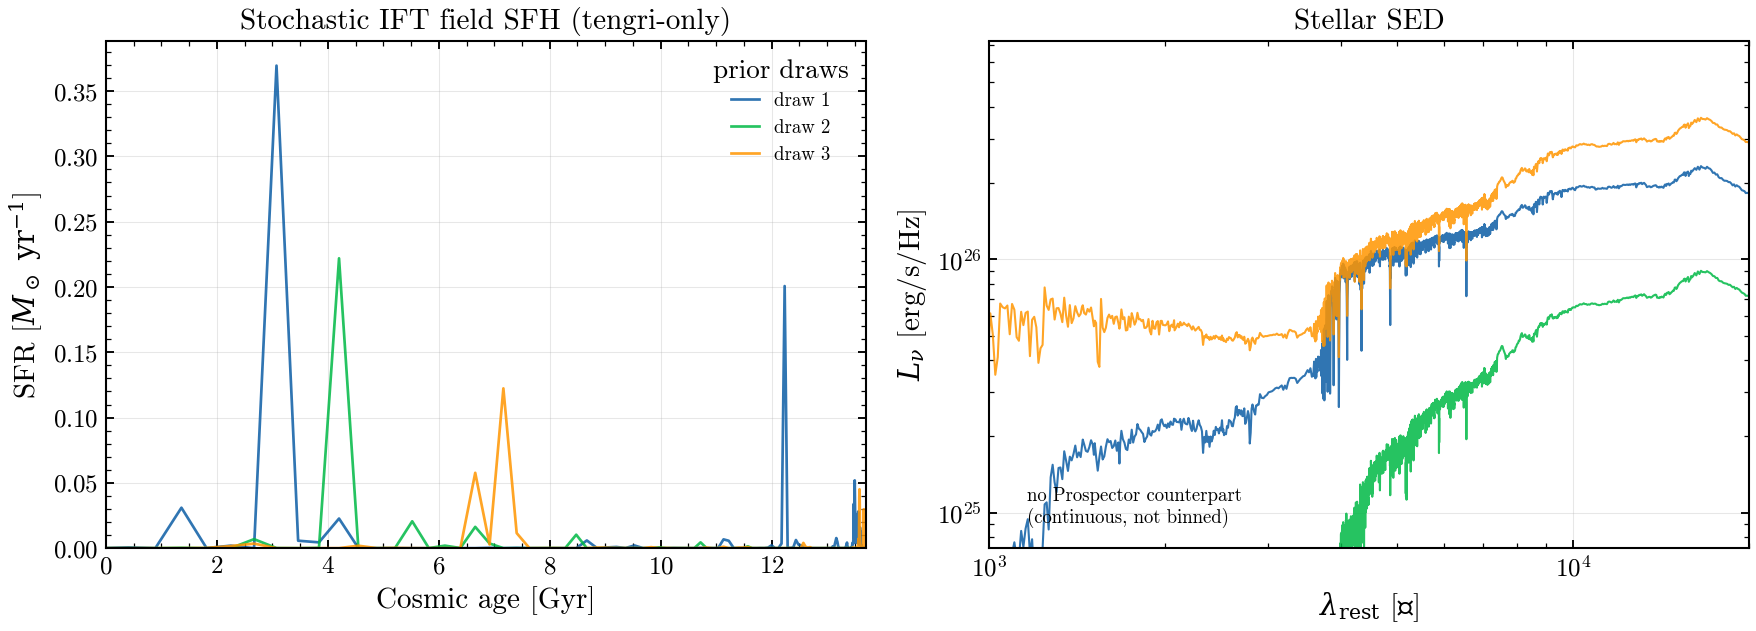

In [10]:
_sfh_field = {
    "type": ["dpl", "field"],
    "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
    "sfh_dpl_alpha": Fixed(2.0),
    "sfh_dpl_beta": Fixed(1.0),
    "sfh_dpl_tau_gyr": Fixed(3.0),
    "sfh_dpl_age_gyr": Fixed(AGE_UNIV_GYR),
    "sfh_field_psd_sigma": Fixed(2.0),
    "sfh_field_psd_tau_myr": Fixed(150.0),
    "all_params": Fixed(DEFAULT),
}
_m_field = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh=_sfh_field,
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)

fig, ax_l, ax_r = _sfr_sed_fig("Stochastic IFT field SFH (tengri-only)")
_field_seds = []
for k, seed in enumerate([3, 11, 29]):
    _draw = _m_field.spec.sample(jax.random.PRNGKey(seed))
    _sf = _m_field.predict_state(_draw)
    _lbt_ift = np.asarray(_sf.derived["sfh_grid_lbt_yr"]) / 1e9
    ax_l.plot(
        AGE_UNIV_GYR - _lbt_ift,
        np.asarray(_sf.derived["sfr_history"]),
        color=f"C{k}",
        linewidth=1.3,
        alpha=0.85,
        label=f"draw {k + 1}",
    )
    ax_r.plot(_sf.wave, _sf.sed_intrinsic, color=f"C{k}", linewidth=1.0, alpha=0.85)
    _field_seds.append((_sf.wave, _sf.sed_intrinsic))
ax_l.legend(fontsize=9, title="prior draws")
ax_r.text(
    0.05,
    0.05,
    "no Prospector counterpart\n(continuous, not binned)",
    transform=ax_r.transAxes,
    fontsize=9,
)
fig.tight_layout()
_anchor_sfr_axis(ax_l)
_tighten_sed_axis(ax_r, *_field_seds)
save_fig("prospector_02e_sfh_ift_field.png")

## §3 Integrated stellar SED

Stellar SED from τ-delayed SFH convolved with MIST+MILES SSPs, with no dust
or nebular. The printed optical ratio matches to unity to ≤0.2%: both engines
use the same dense convolution. Two historical offsets were fixed: the DSPS
age-weight handoff lost 3.8% of the oldest mass (+1.2% optical bias; fixed
#964), and the repackaged grid's FSPS-native L⊙ units were converted with the
IAU constant (0.29%; rescaled at SSP load, #969).

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§3 stellar SED tengri/FSPS optical (3000–10000 Å): median 1.000, P5 0.997, P95 1.002


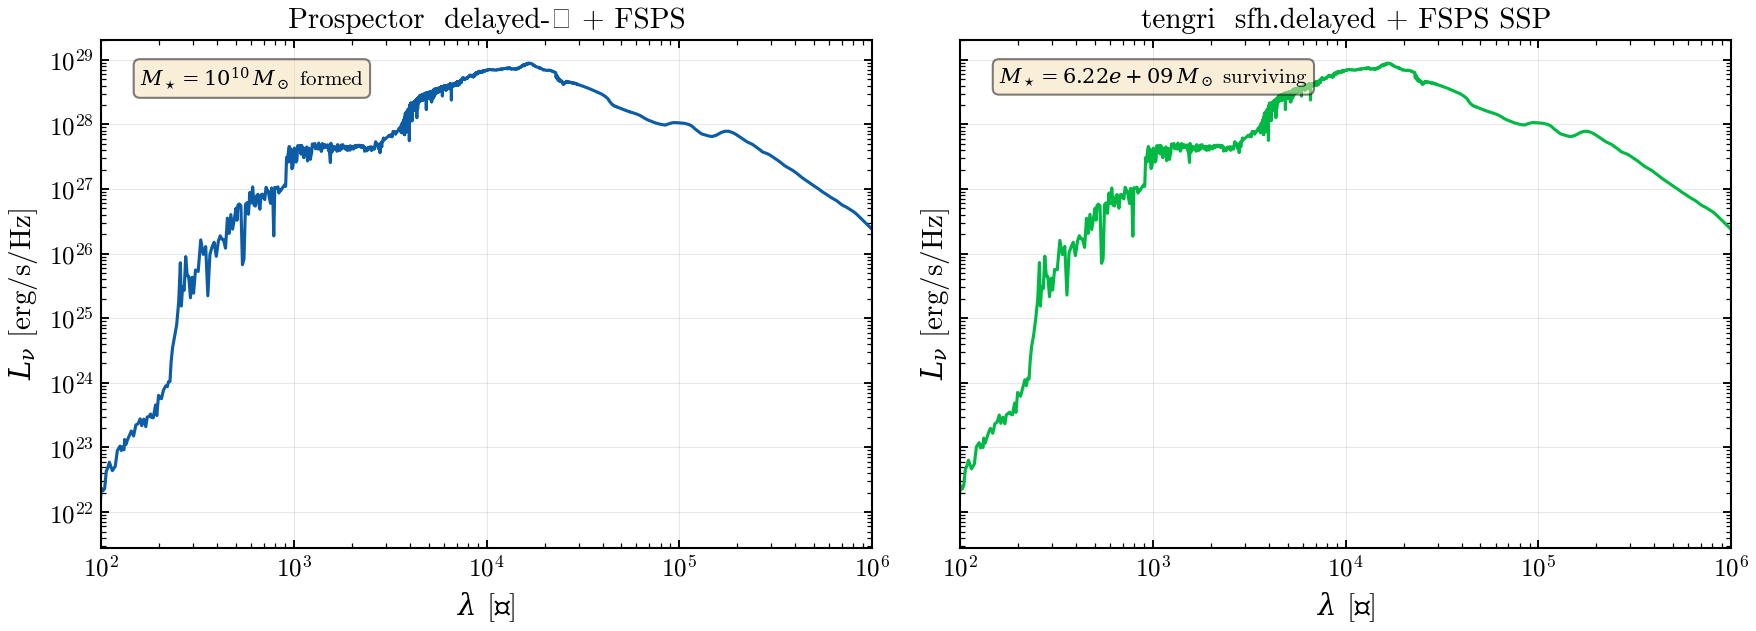

In [11]:
w_p, L_p = P.csp_lnu(logzsol=0.0, tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, sfh=4, av=0.0)
L_p = L_p * MASS_SCALE  # FSPS is per 1 M⊙ formed → scale to the 10^10 M⊙ galaxy

m_stellar = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_stellar = m_stellar.predict_state({})
_assert_comparable(L_p, s_stellar.sed_intrinsic, name="§3 stellar")

fig, ax_l, ax_r = U.two_panel_fig()
U.panel(
    ax_l, ax_r, label_l="Prospector  delayed-τ + FSPS", label_r="tengri  sfh.delayed + FSPS SSP"
)
ax_l.plot(w_p, L_p, "C0-", linewidth=1.5)
ax_l.text(
    0.05,
    0.95,
    rf"$M_\star = 10^{{{LOG_MASS_FIDUCIAL:.0f}}}\,M_\odot$ formed",
    transform=ax_l.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
ax_r.plot(s_stellar.wave, s_stellar.sed_intrinsic, "C1-", linewidth=1.5)
m_star = 10.0 ** float(s_stellar.derived["log_mstar"])
ax_r.text(
    0.05,
    0.95,
    rf"$M_\star = {m_star:.2e}\,M_\odot$ surviving",
    transform=ax_r.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
for ax in (ax_l, ax_r):
    ax.set_xlim(1e2, 1e6)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_03_stellar_sed.png")

_mask_opt = (w_p >= 3000) & (w_p <= 10000)
_t_on_p = U.regrid(np.asarray(s_stellar.wave), np.asarray(s_stellar.sed_intrinsic), w_p)
_ratios = _t_on_p[_mask_opt] / L_p[_mask_opt]
_ratios = _ratios[np.isfinite(_ratios) & (_ratios > 0)]
print(
    f"§3 stellar SED tengri/FSPS optical (3000–10000 Å): "
    f"median {np.median(_ratios):.3f}, P5 {np.percentile(_ratios, 5):.3f}, "
    f"P95 {np.percentile(_ratios, 95):.3f}"
)

## §4 Dust attenuation curves

The three Prospector/FSPS standards — Calzetti+2000 (`dust_type=2`),
Charlot & Fall 2000 (power-law, `dust_type=0`), and Kriek & Conroy 2013
(`dust_type=4`) — compared against tengri's `calzetti`, `power_law`, and
`kriek_conroy`. Both evaluate analytic laws directly, normalized to
`A(λ)/A_V` at 5500 Å.

Kriek & Conroy is compared against FSPS `dust_type=4` (what Prospector uses),
not sedpy's `conroy`. FSPS and sedpy implement KC13 differently: FSPS ties the
2175 Å bump amplitude to slope via KC13 Eq 3, while sedpy uses a fixed
`f_bump = 0.6`. tengri's `kriek_conroy` matches the FSPS construction.

**Verification Status:** CROSSVAL — Attenuation law library

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§4 Kriek & Conroy 2175 Å bump (A_λ/A_V above baseline): FSPS dust_type=4 = 0.166, tengri = 0.165


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


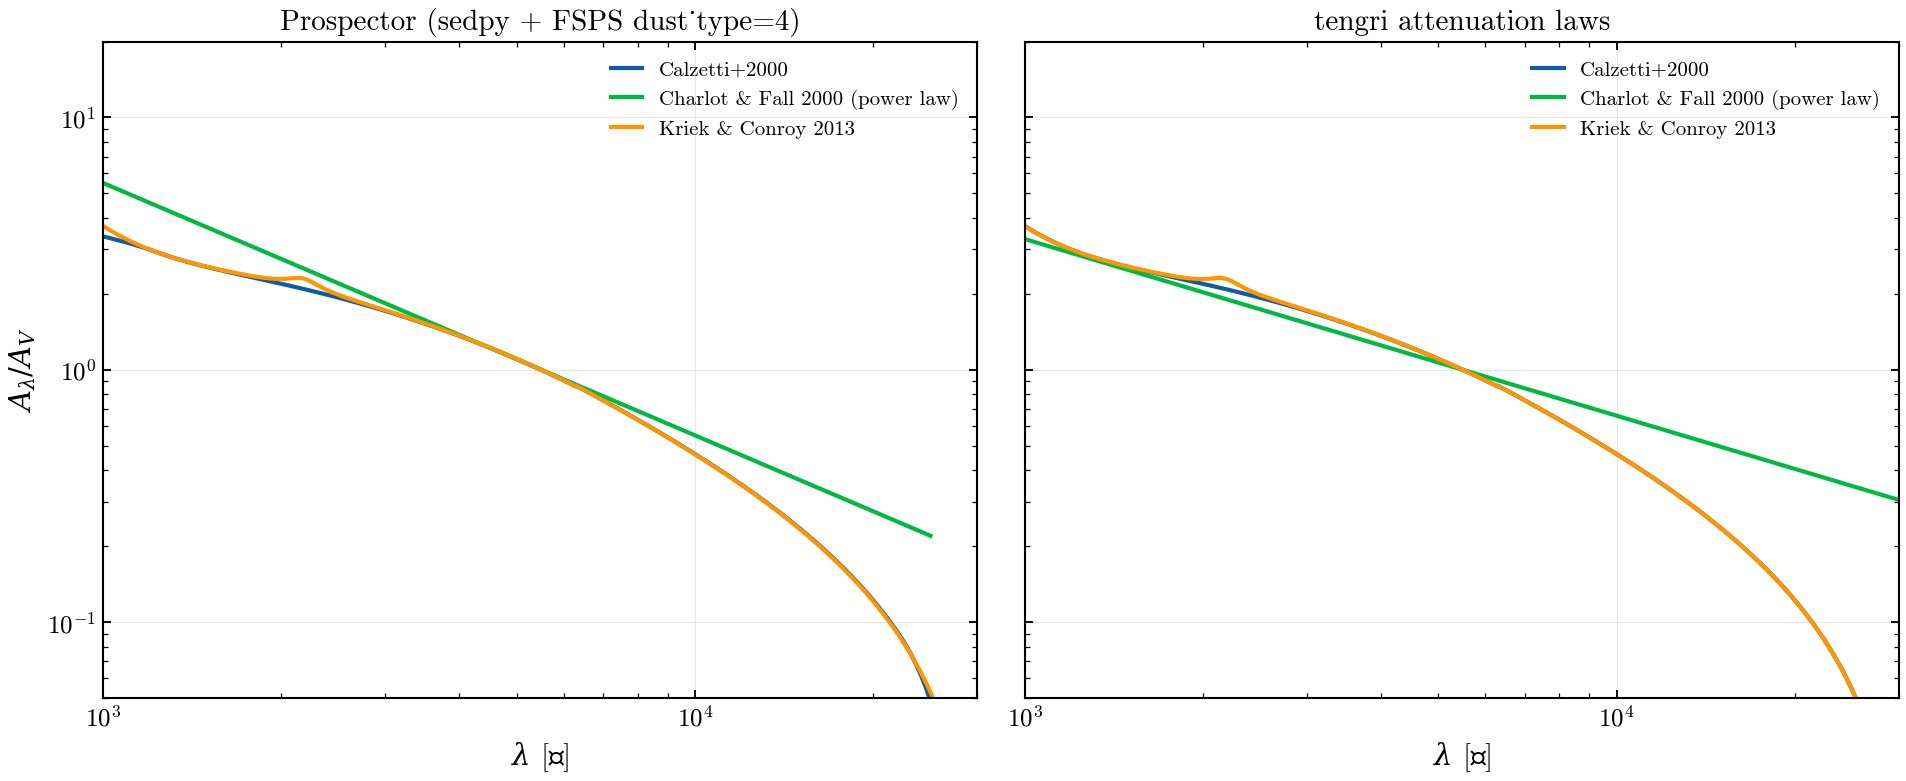

In [12]:
from tengri.dust import list_laws

# (sedpy name, tengri law name, label) for the three matched laws.
_law_pairs = [
    ("calzetti", "calzetti", "Calzetti+2000"),
    ("powerlaw", "power_law", "Charlot & Fall 2000 (power law)"),
    ("conroy", "kriek_conroy", "Kriek & Conroy 2013"),
]
_tengri_laws = list_laws(headline=False).to_dict("fn")  # {name: fn(wave_aa) -> k at tau_V=1}
wave_law = np.logspace(np.log10(1000.0), np.log10(30000.0), 2000)


def _norm_AV(wave, A):
    """A(λ) normalized to A_V at 5500 Å."""
    return A / A[np.argmin(np.abs(wave - 5500.0))]


def _bump_excess(wave, A_over_AV):
    """2175 Å bump height above the local Calzetti baseline, in A_λ/A_V."""
    i = np.argmin(np.abs(wave - 2175.0))
    lo = A_over_AV[np.argmin(np.abs(wave - 1950.0))]
    hi = A_over_AV[np.argmin(np.abs(wave - 2500.0))]
    return float(A_over_AV[i] - 0.5 * (lo + hi))


fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, title in (
    (ax_l, "Prospector (sedpy + FSPS dust_type=4)"),
    (ax_r, "tengri attenuation laws"),
):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$\lambda$ [Å]")
    ax.set_xlim(1e3, 3e4)
    ax.set_ylim(0.05, 20)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
ax_l.set_ylabel(r"$A_\lambda / A_V$")

for sedpy_name, tengri_law, label in _law_pairs:
    if tengri_law == "kriek_conroy":
        # Prospector applies KC13 through FSPS dust_type=4, not sedpy.conroy.
        A_p = P.fsps_kriek_conroy_curve(wave_law)
        w_p = wave_law
    else:
        w_p, A_p = P.attenuation_curve(sedpy_name, av=1.0)
    A_p_norm = _norm_AV(w_p, A_p)
    ax_l.plot(w_p, A_p_norm, linewidth=2.0, label=label)

    # tengri's law functions are JAX-native but accept array-likes; the
    # result is wrapped back to NumPy for plotting.
    A_t = np.asarray(_tengri_laws[tengri_law](wave_law))
    A_t_norm = _norm_AV(wave_law, A_t)
    ax_r.plot(wave_law, A_t_norm, linewidth=2.0, label=label)

    if tengri_law == "kriek_conroy":
        print(
            f"§4 Kriek & Conroy 2175 Å bump (A_λ/A_V above baseline): "
            f"FSPS dust_type=4 = {_bump_excess(w_p, A_p_norm):.3f}, "
            f"tengri = {_bump_excess(wave_law, A_t_norm):.3f}"
        )
ax_l.legend(fontsize=10)
ax_r.legend(fontsize=10)
fig.tight_layout()
save_fig("prospector_04_dust_attenuation.png")

## §5 Attenuation applied

Fiducial galaxy with and without dust. Prospector applies Calzetti as a
single screen at A_V = 1 (FSPS `dust_type=2`, `dust2 = A_V/1.086`,
`dust1 = 0`). tengri matches by putting the full A_V on the diffuse
component and zeroing the birth-cloud term. tengri's `τ_bc` attenuates only
stars younger than ~10 Myr; an even split would under-attenuate the old
population that dominates the 5 Gyr fiducial, leaving the optical ~1.5× too
bright.

**Verification Status:** CROSSVAL — Attenuation law library

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


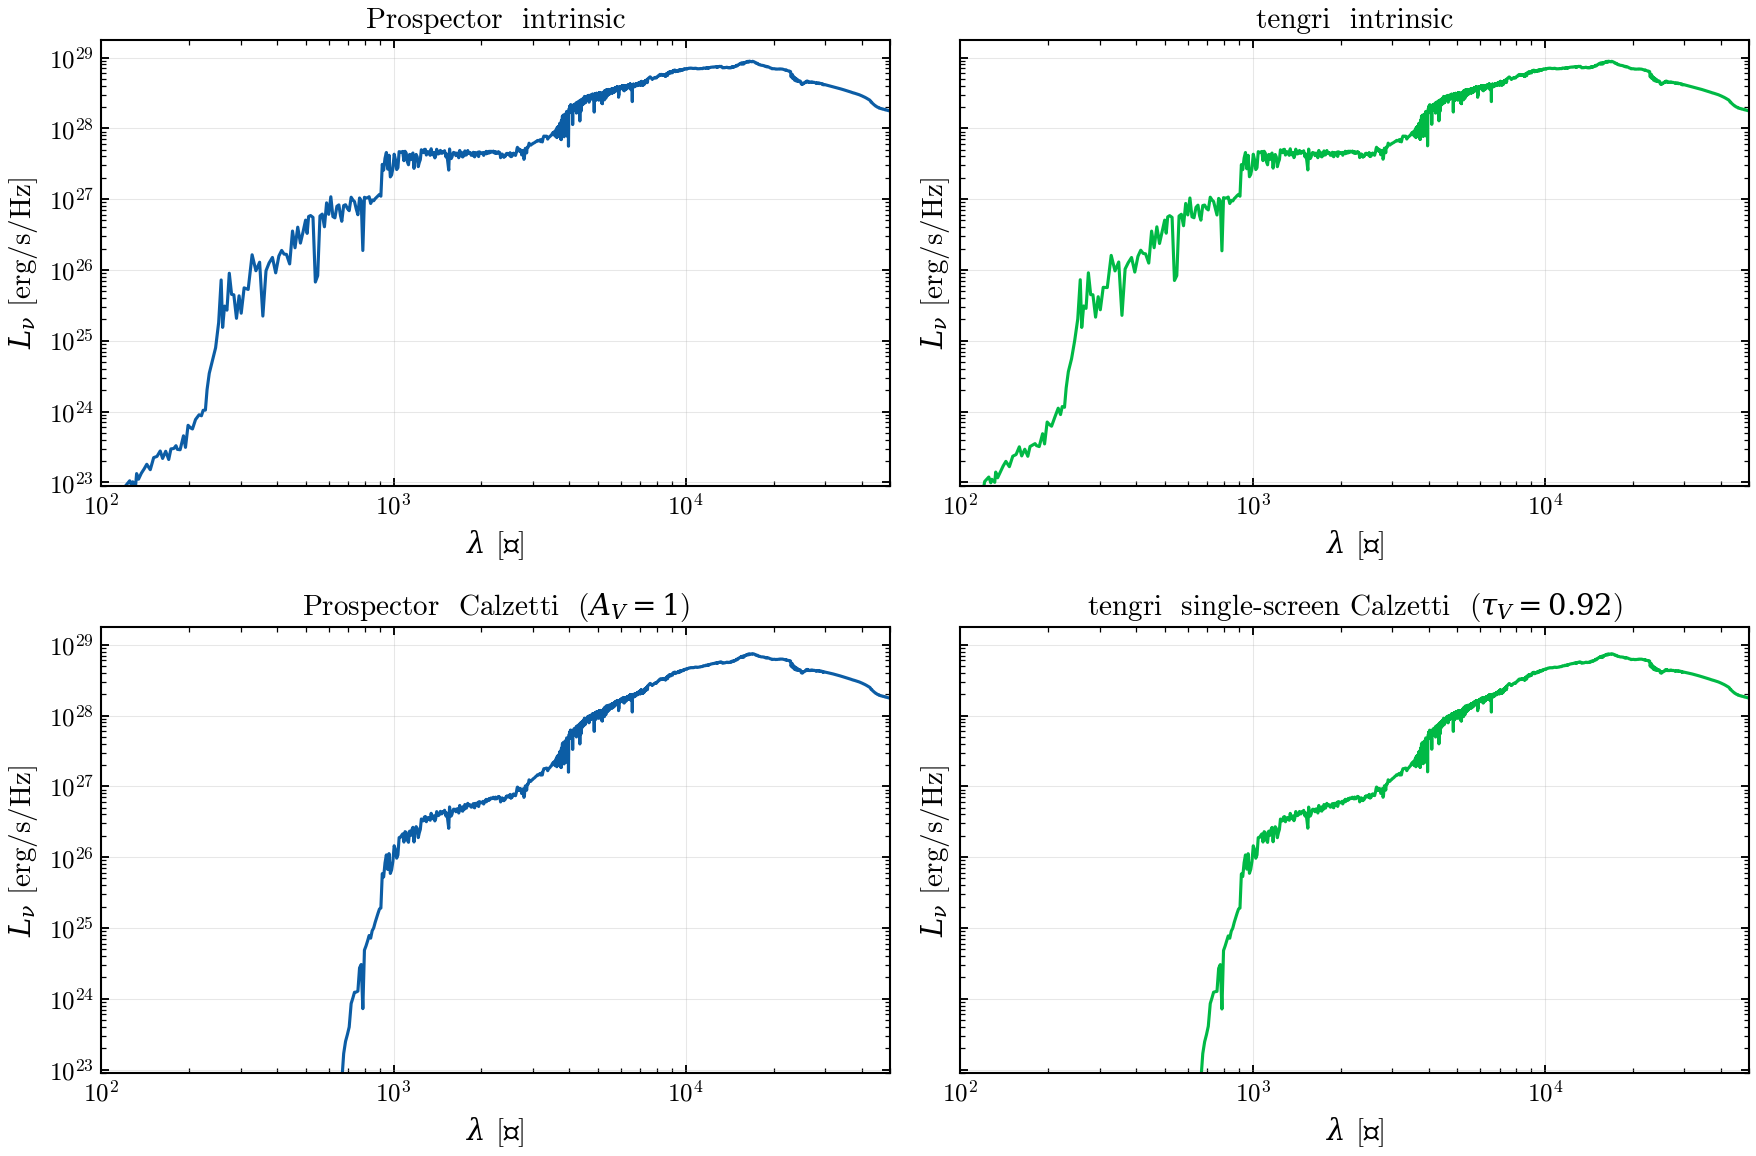

In [13]:
TAU_DIFF = AV_FIDUCIAL / 1.086  # full single screen on the diffuse (all-age) component
TAU_BC = 0.0  # birth-cloud term off — matches FSPS dust1 = 0

w_p_nd, L_p_nd = P.csp_lnu(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, av=0.0)
w_p_d, L_p_d = P.csp_lnu(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, av=AV_FIDUCIAL, dust_type=2)
L_p_nd = L_p_nd * MASS_SCALE
L_p_d = L_p_d * MASS_SCALE

s_nd = s_stellar  # intrinsic reuse from §3 (already at 10^10 M⊙)
m_d = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_d = m_d.predict_state({})
_assert_comparable(L_p_d, s_d.derived["sed_dust_attenuated"], name="§5 dust applied")

fig, ((ax_l1, ax_r1), (ax_l2, ax_r2)) = plt.subplots(2, 2, sharey=True, figsize=(12, 8))
U.panel(ax_l1, ax_r1, label_l="Prospector  intrinsic", label_r="tengri  intrinsic")
U.panel(
    ax_l2,
    ax_r2,
    label_l=rf"Prospector  Calzetti  ($A_V = {AV_FIDUCIAL:g}$)",
    label_r=rf"tengri  single-screen Calzetti  ($\tau_V={TAU_DIFF:.2f}$)",
)
ax_l1.plot(w_p_nd, L_p_nd, "C0-", linewidth=1.5)
ax_r1.plot(s_nd.wave, s_nd.sed_intrinsic, "C1-", linewidth=1.5)
ax_l2.plot(w_p_d, L_p_d, "C0-", linewidth=1.5)
ax_r2.plot(s_d.wave, s_d.derived["sed_dust_attenuated"], "C1-", linewidth=1.5)
_ymax = float(np.asarray(s_nd.sed_intrinsic).max())
for ax in (ax_l1, ax_r1, ax_l2, ax_r2):
    ax.set_xlim(1e2, 5e4)
    ax.set_ylim(_ymax * 1e-6, _ymax * 2)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_05_dust_applied.png")

## §6 Dust IR re-emission and energy balance

Prospector re-emits absorbed stellar UV/optical through Draine & Li (2007)
templates via `add_dust_emission=True`; tengri uses its own DL07 grid with
energy balance enforced to floating point.

At matched parameters, both DL07 SEDs agree in shape (both peak ~130 μm;
30–100 μm track to ~6%). The PDR luminosity weighting is critical: `γ` is
dust-mass fraction, but PDR dust emits `R ≈ 14×` more per unit mass (DL07
Eq. 33); with that weight the warm component lands where FSPS places it.

Two conventions differ. FSPS ships DL07 with the 3.3 μm PAH feature halved
(stated in `dust/dustem` headers); tengri carries the original, and the grids
agree to within 1.2% everywhere else. Bands on rest-frame 3–3.6 μm
(WISE W1 at low z) inherit that choice. And FIR amplitude differs by construction:
FSPS re-emits all absorbed luminosity (measured `L_IR/L_abs = 0.9996`),
including LyC; tengri's canonical balance excludes λ < 912 Å (those photons
re-emerge as nebular, the CIGALE convention). At this fiducial, LyC
carries ~11% of absorbed energy, so tengri's far-IR sits ~11% below Prospector.
Both ratios are printed; opt-in `dust={'eb_include_lyc': True}` closes the gap.

**Verification Status:** CROSSVAL — Dust IR emission physics (MBB, Casey12, CMB)

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§6 tengri energy balance: L_abs = 2.195e+43, L_IR = 2.195e+43, resid = 0.00e+00


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§6 FSPS far-IR peak at 142 µm
§6 FIR amplitude tengri/FSPS (30–1000 µm): 0.894 (canonical LyC-masked) → 0.999 with eb_include_lyc=True (FSPS parity)


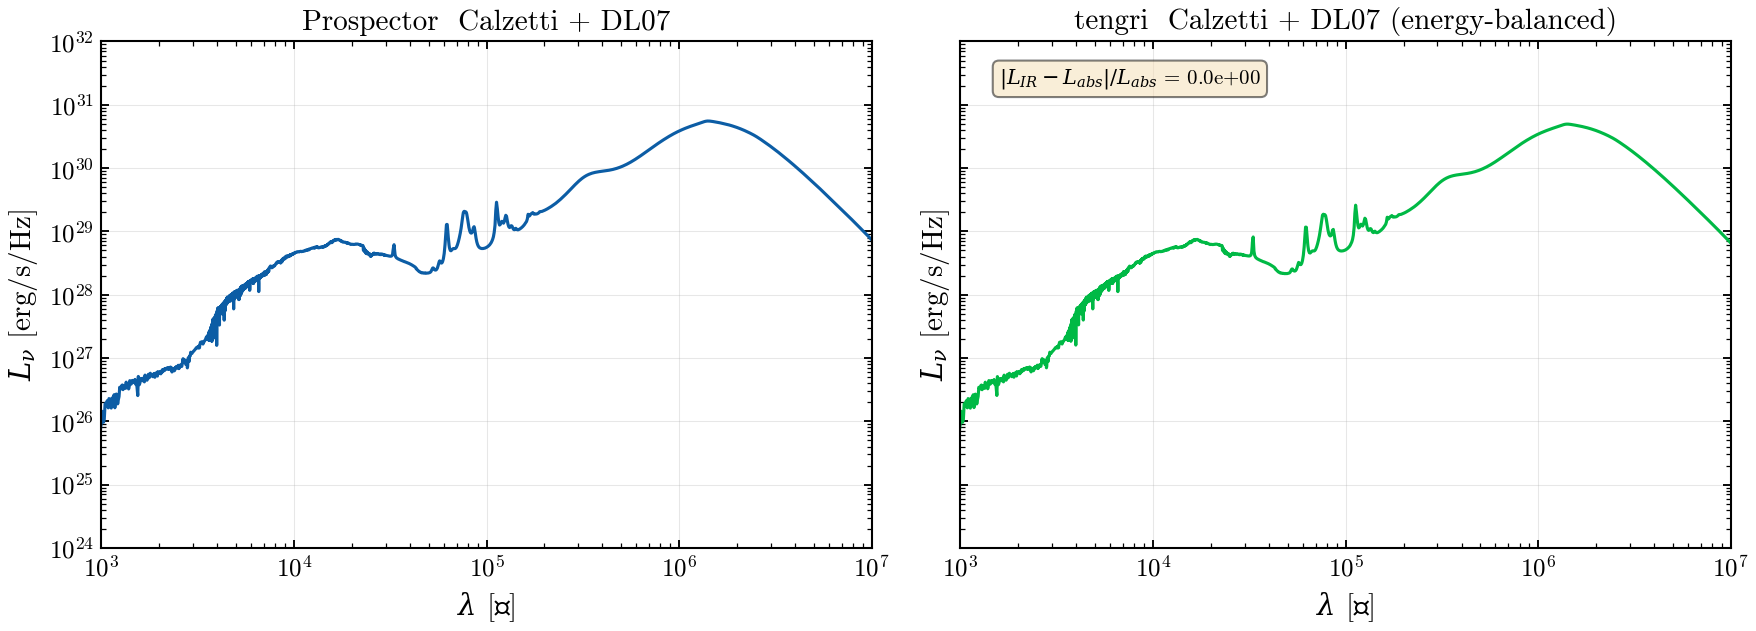

In [14]:
w_p_ir, L_p_ir = P.csp_lnu(
    tau=TAU_GYR_FIDUCIAL,
    tage=AGE_GYR_FIDUCIAL,
    av=AV_FIDUCIAL,
    dust_type=2,
    add_dust_emission=True,
    duste_qpah=QPAH_FIDUCIAL,
    duste_umin=UMIN_FIDUCIAL,
    duste_gamma=GAMMA_FIDUCIAL,
)
L_p_ir = L_p_ir * MASS_SCALE

m_ir = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    dust_emission={
        "type": "draine_li2007",
        "qpah": Fixed(QPAH_FIDUCIAL),
        "umin": Fixed(UMIN_FIDUCIAL),
        "gamma_dl": Fixed(GAMMA_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_ir = m_ir.predict_state({})
_L_abs = float(np.asarray(s_ir.derived["L_absorbed"]))
_L_ir = float(np.asarray(s_ir.derived["L_ir"]))
_eb_resid = abs(_L_ir - _L_abs) / max(_L_abs, 1e-30)
print(
    f"§6 tengri energy balance: L_abs = {_L_abs:.3e}, L_IR = {_L_ir:.3e}, resid = {_eb_resid:.2e}"
)

fig, ax_l, ax_r = U.two_panel_fig()
U.panel(
    ax_l,
    ax_r,
    label_l="Prospector  Calzetti + DL07",
    label_r="tengri  Calzetti + DL07 (energy-balanced)",
)
ax_l.plot(w_p_ir, L_p_ir, "C0-", linewidth=1.5)
sed_full_t = np.asarray(s_ir.derived["sed_dust_attenuated"]) + np.asarray(
    s_ir.derived["sed_dust_ir"]
)
ax_r.plot(s_ir.wave, sed_full_t, "C1-", linewidth=1.5)
ax_r.text(
    0.05,
    0.95,
    rf"$|L_{{IR}} - L_{{abs}}| / L_{{abs}}$ = {_eb_resid:.1e}",
    transform=ax_r.transAxes,
    fontsize=10,
    va="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)
for ax in (ax_l, ax_r):
    ax.set_xlim(1e3, 1e7)
    ax.set_ylim(1e24, 1e32)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_06_dust_ir.png")

# Far-IR peak location, a robust scalar diagnostic.
_p_fir = w_p_ir[(w_p_ir > 1e5) & (w_p_ir < 1e7)]
_L_fir = L_p_ir[(w_p_ir > 1e5) & (w_p_ir < 1e7)]
_peak_p = _p_fir[np.argmax(_L_fir)]
print(f"§6 FSPS far-IR peak at {_peak_p / 1e4:.0f} µm")

# FIR amplitude vs FSPS — quantifies the LyC energy-balance convention
# (#961). The default (LyC-masked, #922) sits ~11 % low; the opt-in
# `eb_include_lyc` FSPS-parity mode re-emits the full absorbed luminosity
# like FSPS and closes the gap.
_fir_win = (w_p_ir > 3e5) & (w_p_ir < 1e7)  # 30–1000 µm
_t_on_p_ir = U.regrid(np.asarray(s_ir.wave), sed_full_t, w_p_ir)
_fir_ratio = float(np.median(_t_on_p_ir[_fir_win] / L_p_ir[_fir_win]))

m_ir_fsps = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "eb_include_lyc": True,  # FSPS parity: LyC heats dust too (#961)
        "all_params": Fixed(DEFAULT),
    },
    dust_emission={
        "type": "draine_li2007",
        "qpah": Fixed(QPAH_FIDUCIAL),
        "umin": Fixed(UMIN_FIDUCIAL),
        "gamma_dl": Fixed(GAMMA_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_ir_fsps = m_ir_fsps.predict_state({})
_sed_fsps_mode = np.asarray(s_ir_fsps.derived["sed_dust_attenuated"]) + np.asarray(
    s_ir_fsps.derived["sed_dust_ir"]
)
_t_fsps_on_p = U.regrid(np.asarray(s_ir_fsps.wave), _sed_fsps_mode, w_p_ir)
_fir_ratio_fsps = float(np.median(_t_fsps_on_p[_fir_win] / L_p_ir[_fir_win]))
print(
    f"§6 FIR amplitude tengri/FSPS (30–1000 µm): "
    f"{_fir_ratio:.3f} (canonical LyC-masked) → "
    f"{_fir_ratio_fsps:.3f} with eb_include_lyc=True (FSPS parity)"
)

## §7 Panchromatic SED

Full SED from rest-UV to far-IR: stellar + nebular + dust attenuation + DL07 IR.
Percent-level disagreements from §3–§6 (and §8's nebular gap) stack here; the
headline is overall shape, not bit-for-bit agreement at individual wavelengths.

**Verification Status:** CROSSVAL — Photometry projection

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


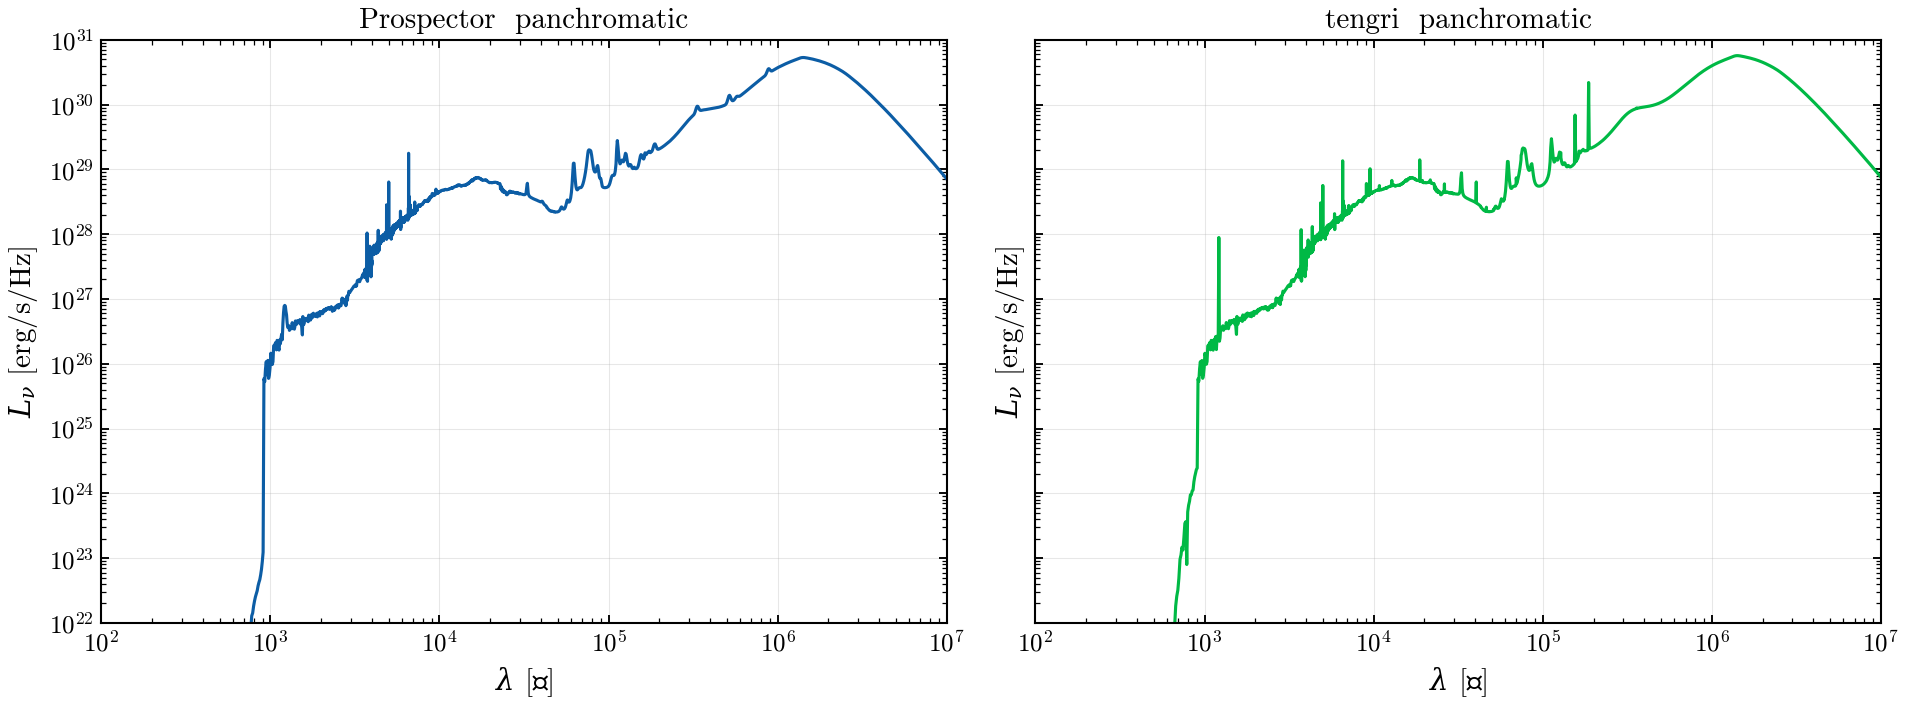

In [15]:
w_p_full, L_p_full = P.csp_lnu(
    tau=TAU_GYR_FIDUCIAL,
    tage=AGE_GYR_FIDUCIAL,
    av=AV_FIDUCIAL,
    dust_type=2,
    add_dust_emission=True,
    duste_qpah=QPAH_FIDUCIAL,
    duste_umin=UMIN_FIDUCIAL,
    duste_gamma=GAMMA_FIDUCIAL,
    add_neb_emission=True,
    gas_logu=-2.0,
    gas_logz=0.0,
)
L_p_full = L_p_full * MASS_SCALE

m_full = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "type": "two_component",
        "law_bc": "calzetti",
        "law_diff": "calzetti",
        "tau_bc": Fixed(TAU_BC),
        "tau_diff": Fixed(TAU_DIFF),
        "all_params": Fixed(DEFAULT),
    },
    dust_emission={
        "type": "draine_li2007",
        "qpah": Fixed(QPAH_FIDUCIAL),
        "umin": Fixed(UMIN_FIDUCIAL),
        "gamma_dl": Fixed(GAMMA_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_full = m_full.predict_state({})

fig, ax_l, ax_r = U.two_panel_fig(figsize=(13, 5))
U.panel(ax_l, ax_r, label_l="Prospector  panchromatic", label_r="tengri  panchromatic")
ax_l.plot(w_p_full, L_p_full, "C0-", linewidth=1.5)
_sed_full_t = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)
ax_r.plot(s_full.wave, _sed_full_t, "C1-", linewidth=1.5)
for ax in (ax_l, ax_r):
    ax.set_xlim(1e2, 1e7)
    ax.set_ylim(1e22, 1e31)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_07_panchromatic.png")

## §8 Nebular emission

FSPS uses Byler+2017 Cloudy grids parametrized by `(gas_logu, gas_logz)`;
tengri uses Cue (Li et al. 2025), a neural emulator on a different Cloudy
version. The panel reports integrated, continuum-subtracted line luminosity
(width- and grid-independent).

**Verification Status:** CROSSVAL — Cloudy grid / Cue vs FSPS baked-in

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§8 integrated line luminosity (tengri Cue / FSPS Byler+2017):
    Hα 6563 Å: FSPS 3.20e+43, tengri 3.05e+43 erg/s → 0.95×
    [O III] 5007 Å: FSPS 2.33e+43, tengri 2.04e+43 erg/s → 0.87×
    Hβ 4861 Å: FSPS 1.05e+43, tengri 1.07e+43 erg/s → 1.03×


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


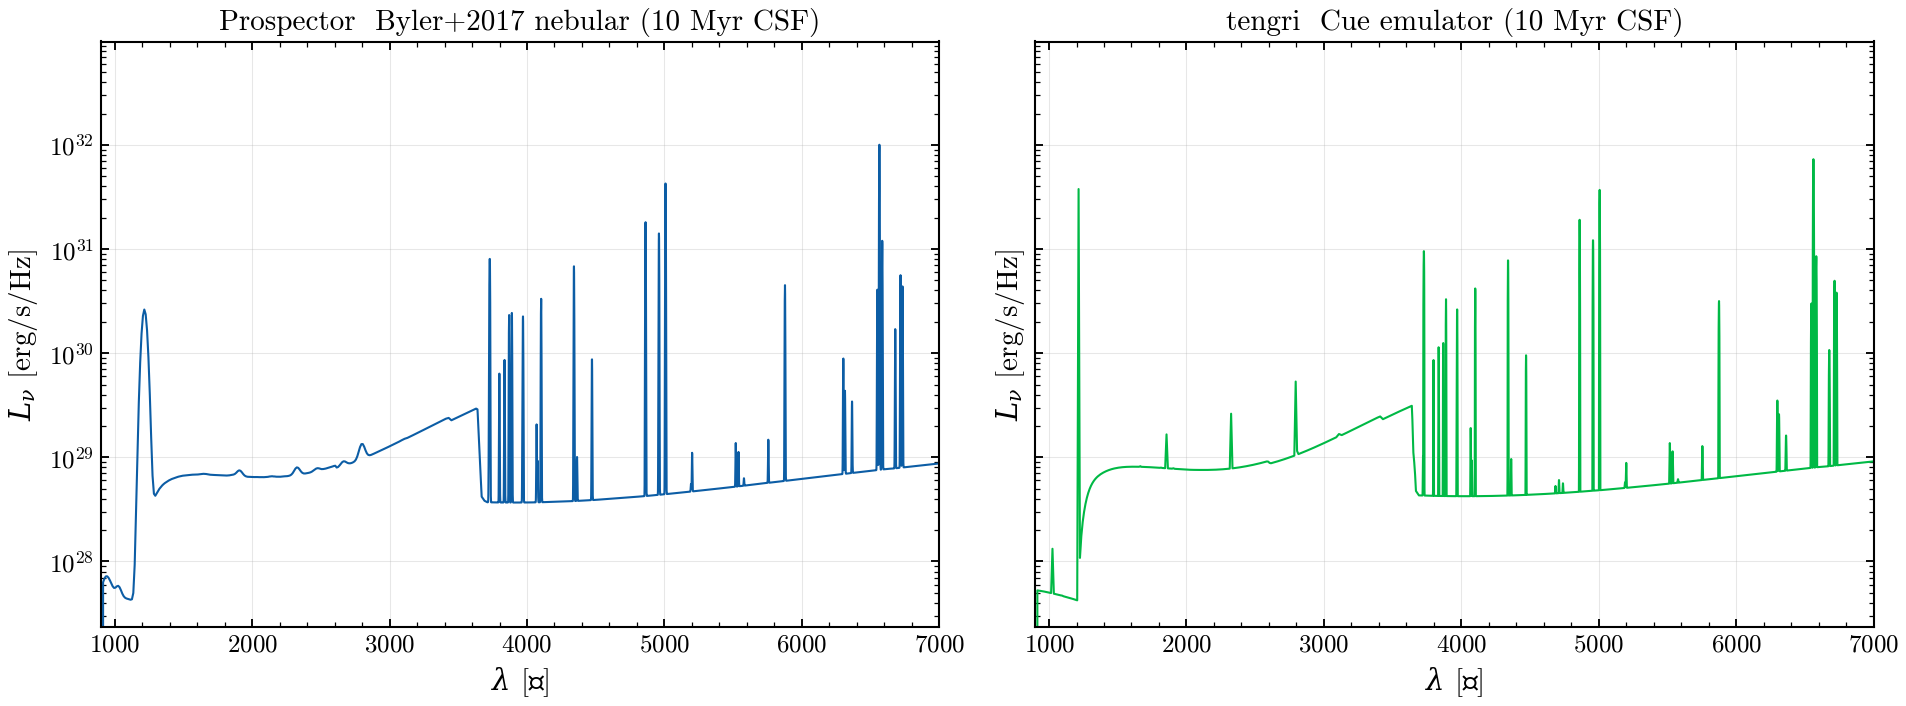

In [16]:
NEB_AGE = 0.01  # Gyr — a young constant-SFR population, where lines dominate

# FSPS nebular isolated as (neb on) − (neb off) at the same SFH.
w_p_neb, L_p_neb = P.isolate(
    dict(sfh=1, const=1.0, tage=NEB_AGE, add_neb_emission=True, gas_logu=-2.0, gas_logz=0.0),
    dict(sfh=1, const=1.0, tage=NEB_AGE),
)
L_p_neb = np.clip(L_p_neb, 0.0, None)

m_neb = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "const",
        "start_gyr": Fixed(NEB_AGE),
        "end_gyr": Fixed(0.0),
        "log_total_mass": Fixed(9.0),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    neb={
        "type": "cue",
        "neb_logU": Fixed(-2.0),
        "neb_logZ_gas": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_neb = m_neb.predict_state({})
L_t_neb = np.asarray(s_neb.derived["sed_nebular"])

# Rescale FSPS nebular to the same formed mass as the tengri build
# (tengri log_total_mass=9; FSPS curve is per 1 M⊙ formed).
L_p_neb_scaled = L_p_neb * 10.0**9.0

fig, ax_l, ax_r = U.two_panel_fig(figsize=(13, 5))
U.panel(
    ax_l,
    ax_r,
    label_l="Prospector  Byler+2017 nebular (10 Myr CSF)",
    label_r="tengri  Cue emulator (10 Myr CSF)",
)
ax_l.plot(w_p_neb, L_p_neb_scaled, "C0-", linewidth=1.0)
ax_r.plot(s_neb.wave, L_t_neb, "C1-", linewidth=1.0)
for ax in (ax_l, ax_r):
    ax.set_xlim(900, 7000)
    ax.set_xscale("linear")
    ax.grid(True, alpha=0.3)
# Integrated line luminosity (width- and grid-independent). A single-bin peak
# ratio measures line width, not luminosity — Cue broadens its lines while FSPS
# places them at the grid resolution, so a peak ratio is meaningless. Compare
# the brightest optical lines by their continuum-subtracted integrated flux.
_w_t = np.asarray(s_neb.wave)
print("§8 integrated line luminosity (tengri Cue / FSPS Byler+2017):")
for _c, _name in [(6563.0, "Hα"), (5007.0, "[O III]"), (4861.0, "Hβ")]:
    _lp = U.line_lum(w_p_neb, L_p_neb_scaled, _c)
    _lt = U.line_lum(_w_t, L_t_neb, _c)
    if _lp > 0:
        print(f"    {_name} {_c:.0f} Å: FSPS {_lp:.2e}, tengri {_lt:.2e} erg/s → {_lt / _lp:.2f}×")
fig.tight_layout()
save_fig("prospector_08_nebular.png")

## §9 AGN — Nenkova (2008) torus

Prospector's AGN component is the FSPS dust torus (Nenkova et al. 2008, CLUMPY
models), switched on via `fagn > 0` and shaped by `agn_tau`. It reprocesses
fraction `fagn` of stellar bolometric luminosity into mid-IR torus emission
(no separate accretion-disc continuum). tengri's `agn.torus = "nenkova"` is
the matching block.

FSPS' torus luminosity is read from the difference (AGN on − off), and the
same bolometric luminosity is fed into tengri. tengri's `nenkova` block
interpolates the same FSPS CLUMPY template library
(`Nenkova08_y010_torusg_n10_q2.0`) with a differentiable triweight kernel in
`agn_tau` (a fitted parameter, not frozen). At matched bolometric luminosity
both trace the same templates: mid-IR peak and 10 µm silicate feature
coincide.

**Verification Status:** CROSSVAL — Nenkova+08 (CLUMPY) torus

§9 FSPS torus L_bol = 2.243e+43 erg/s = 10^9.77 L⊙


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§9 torus mid-IR peak: FSPS 22.1 µm, tengri 22.1 µm


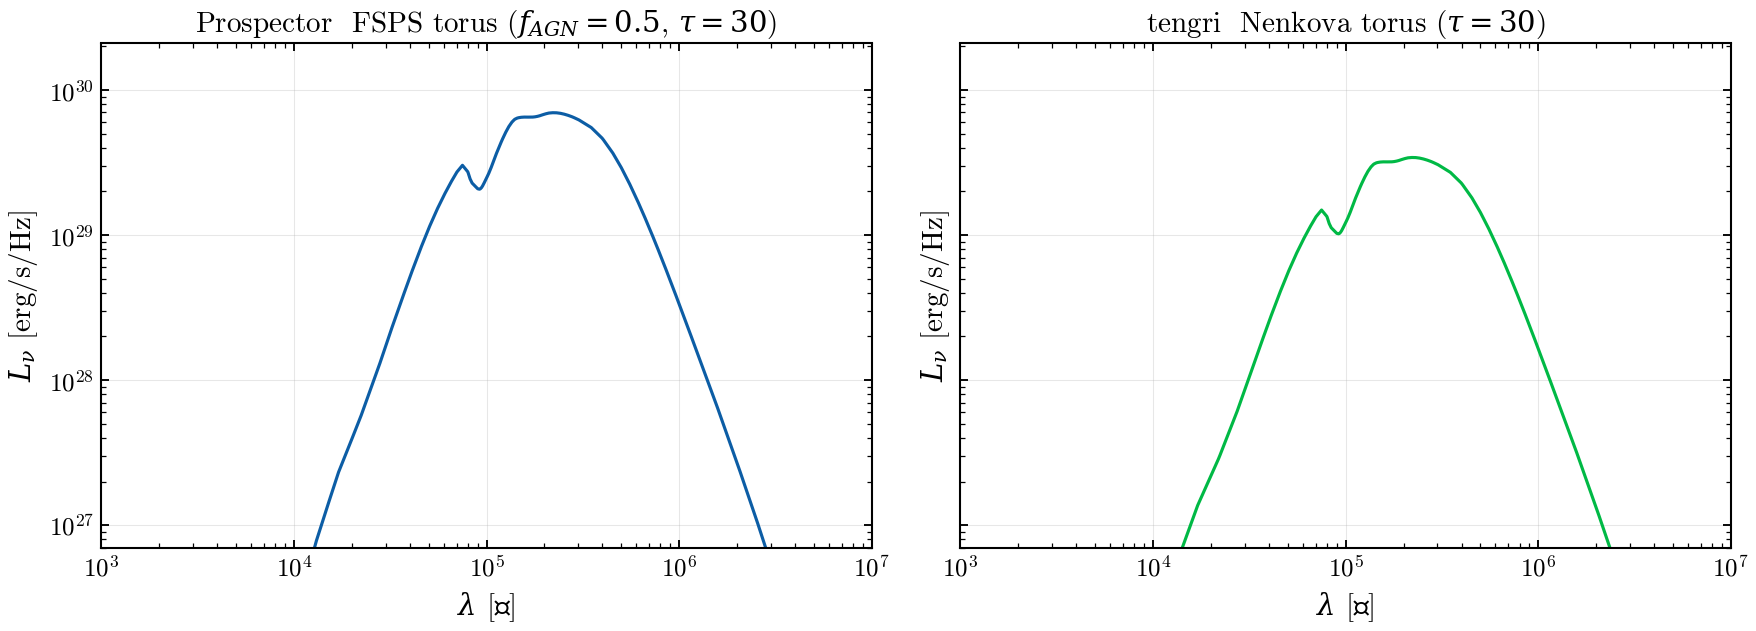

In [17]:
FAGN = 0.5
AGN_TAU = 30.0

# FSPS torus isolated as (fagn on) − (fagn off), and its bolometric.
w_p_agn, L_p_agn = P.isolate(
    dict(
        tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL, add_agn_dust=True, fagn=FAGN, agn_tau=AGN_TAU
    ),
    dict(tau=TAU_GYR_FIDUCIAL, tage=AGE_GYR_FIDUCIAL),
)
L_p_agn = np.clip(L_p_agn, 0.0, None)
# Bolometric of the FSPS torus per 1 M⊙ formed [erg/s], integrated over ν,
# then scaled to the 10^10 M⊙ galaxy. agn_log_lbol = log10(L_torus / L⊙).
_nu = U.C_ANGSTROM_PER_S / w_p_agn[::-1]
_L_agn_bol_erg = float(np.trapezoid(L_p_agn[::-1], _nu)) * MASS_SCALE
# tengri interprets agn_log_lbol with its own (IAU) L⊙, so convert the
# FSPS-derived erg/s value through tengri's units module (#969).
_L_agn_bol_lsun = float(tengri.units.erg_per_s_to_lsun(_L_agn_bol_erg))
_agn_log_lbol = float(np.log10(_L_agn_bol_lsun))
L_p_agn = L_p_agn * MASS_SCALE  # plot the 10^10 M⊙ galaxy's torus
print(f"§9 FSPS torus L_bol = {_L_agn_bol_erg:.3e} erg/s = 10^{_agn_log_lbol:.2f} L⊙")

m_agn = SEDModel.build(
    ssp_data=ssp,
    met=MET_FIDUCIAL,
    sfh={
        "type": "delayed",
        "tau_gyr": Fixed(TAU_GYR_FIDUCIAL),
        "age_gyr": Fixed(AGE_GYR_FIDUCIAL),
        "log_total_mass": Fixed(LOG_MASS_FIDUCIAL),
        "all_params": Fixed(DEFAULT),
    },
    dust_attenuation={
        "law": "power_law",
        "type": "two_component",
        "tau_bc": Fixed(0.0),
        "tau_diff": Fixed(0.0),
        "all_params": Fixed(DEFAULT),
    },
    agn={
        "type": "composable",
        "disc": {"type": "none"},
        "torus": {"type": "nenkova", "agn_tau": Fixed(AGN_TAU), "all_params": Fixed(DEFAULT)},
        "agn_log_lbol": Fixed(_agn_log_lbol),
        "all_params": Fixed(DEFAULT),
    },
    redshift=Fixed(0.0),
)
s_agn = m_agn.predict_state({})
L_t_agn = np.asarray(s_agn.derived["sed_agn"])

fig, ax_l, ax_r = U.two_panel_fig()
U.panel(
    ax_l,
    ax_r,
    label_l=rf"Prospector  FSPS torus ($f_{{AGN}}={FAGN:g}$, $\tau={AGN_TAU:g}$)",
    label_r=rf"tengri  Nenkova torus ($\tau={AGN_TAU:g}$)",
)
ax_l.plot(w_p_agn, L_p_agn, "C0-", linewidth=1.5)
ax_r.plot(s_agn.wave, L_t_agn, "C1-", linewidth=1.5)
_peak_agn = max(float(np.max(L_p_agn)), float(np.max(L_t_agn)))
for ax in (ax_l, ax_r):
    ax.set_xlim(1e3, 1e7)
    ax.set_ylim(_peak_agn * 1e-3, _peak_agn * 3)
    ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_09_agn_nenkova.png")

_peak_p_agn = w_p_agn[(w_p_agn > 1e4)][np.argmax(L_p_agn[(w_p_agn > 1e4)])]
_w_t_agn = np.asarray(s_agn.wave)
_peak_t_agn = _w_t_agn[(_w_t_agn > 1e4)][np.argmax(L_t_agn[(_w_t_agn > 1e4)])]
print(f"§9 torus mid-IR peak: FSPS {_peak_p_agn / 1e4:.1f} µm, tengri {_peak_t_agn / 1e4:.1f} µm")

## §12 IGM transmission — Madau (1995)

FSPS applies Madau (1995) for Lyman-line and Lyman-continuum absorption via
`add_igm_absorption=True`. tengri ships the same Madau form alongside Inoue+2014
as default. At the same redshift the residual is the difference between the two
Madau coefficient implementations. (IGM numbering follows the CIGALE master
sequence; §10 X-ray and §11 radio are absent from Prospector.)

**Verification Status:** CROSSVAL — Inoue+2014 IGM transmission

Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


§12 Madau IGM at z=4 (950–1216 Å): max |Δ| = 1.118e-02, median |Δ| = 1.035e-02


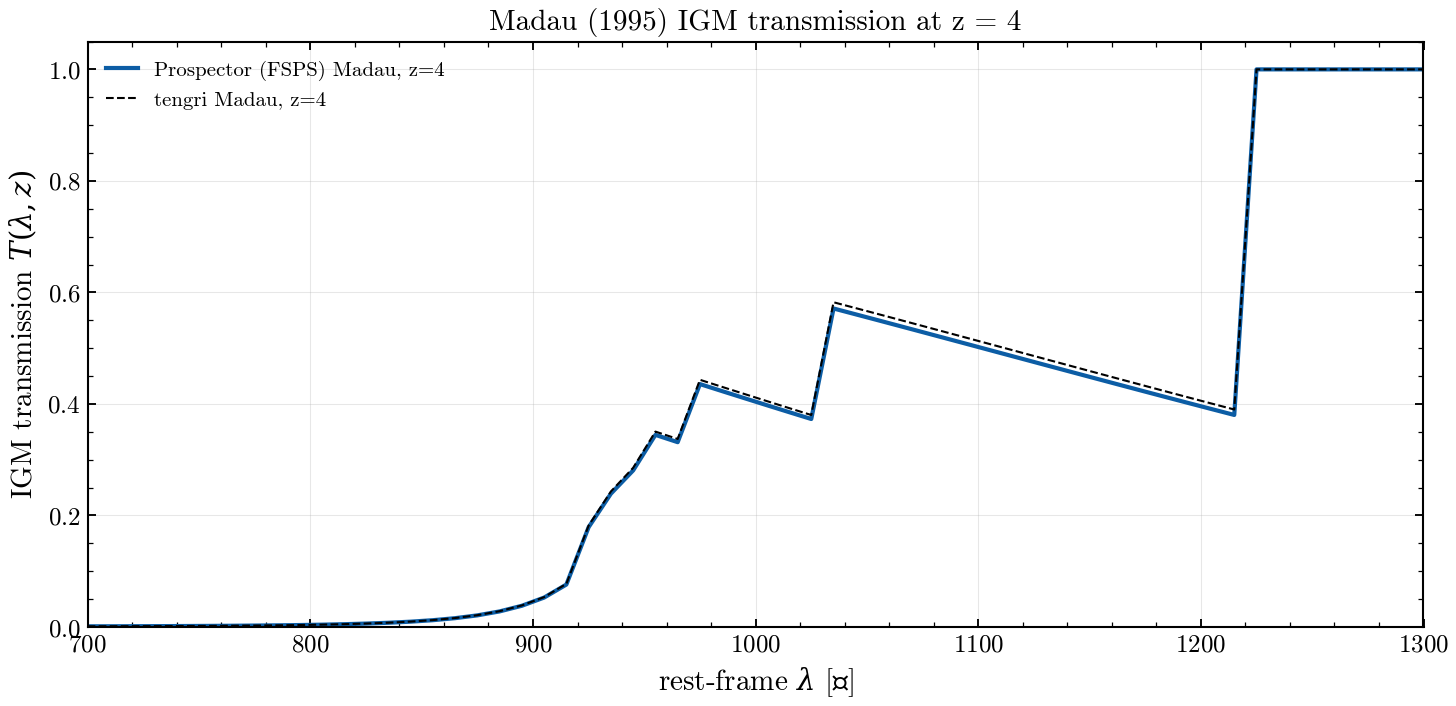

In [18]:
from tengri.igm import igm_transmission_madau

Z_IGM = 4.0
w_p_igm, T_p_igm = P.igm_transmission(zred=Z_IGM, age_gyr=0.05)

# tengri's Madau is parametrized on observed-frame wavelengths.
wave_obs = w_p_igm * (1.0 + Z_IGM)
T_t_igm = np.asarray(igm_transmission_madau(wave_obs, np.asarray(Z_IGM)))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(w_p_igm, T_p_igm, "C0-", linewidth=2.0, label=f"Prospector (FSPS) Madau, z={Z_IGM:g}")
ax.plot(w_p_igm, T_t_igm, "k--", linewidth=1.0, label=f"tengri Madau, z={Z_IGM:g}")
ax.set_xlabel(r"rest-frame $\lambda$ [Å]")
ax.set_ylabel(r"IGM transmission $T(\lambda, z)$")
ax.set_xlim(700, 1300)
ax.set_ylim(0, 1.05)
ax.set_title(f"Madau (1995) IGM transmission at z = {Z_IGM:g}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_12_igm_madau.png")

# Quantify agreement over the Lyman-α forest window.
_win = (w_p_igm >= 950) & (w_p_igm <= 1216)
_igm_diff = np.abs(T_t_igm[_win] - T_p_igm[_win])
print(
    f"§12 Madau IGM at z={Z_IGM:g} (950–1216 Å): "
    f"max |Δ| = {_igm_diff.max():.3e}, median |Δ| = {np.median(_igm_diff):.3e}"
)

## tengri in Prospector-mode — full-SED head-to-head

Full forward model: tengri configured to emulate Prospector end to end
(FSPS MIST+MILES SSP, τ-delayed SFH, Calzetti dust, DL07 IR, and nebular)
overlaid on FSPS at matched parameters (§7 configuration), with the
fractional residual `tengri / FSPS − 1` and a ±25% band below. Optical
agreement is reported as a normalization ratio and robust 16–84% spread
(tracking the stellar continuum). Emission lines and sub-912 Å are sparse
points the percentile rejects; the spread is a continuum metric.

full-SED head-to-head tengri/FSPS optical (1000–10000 Å): normalization 1.00×, 16–84% spread 1.00–1.00×


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\xc5' [U+c5], substituting with a dummy symbol.


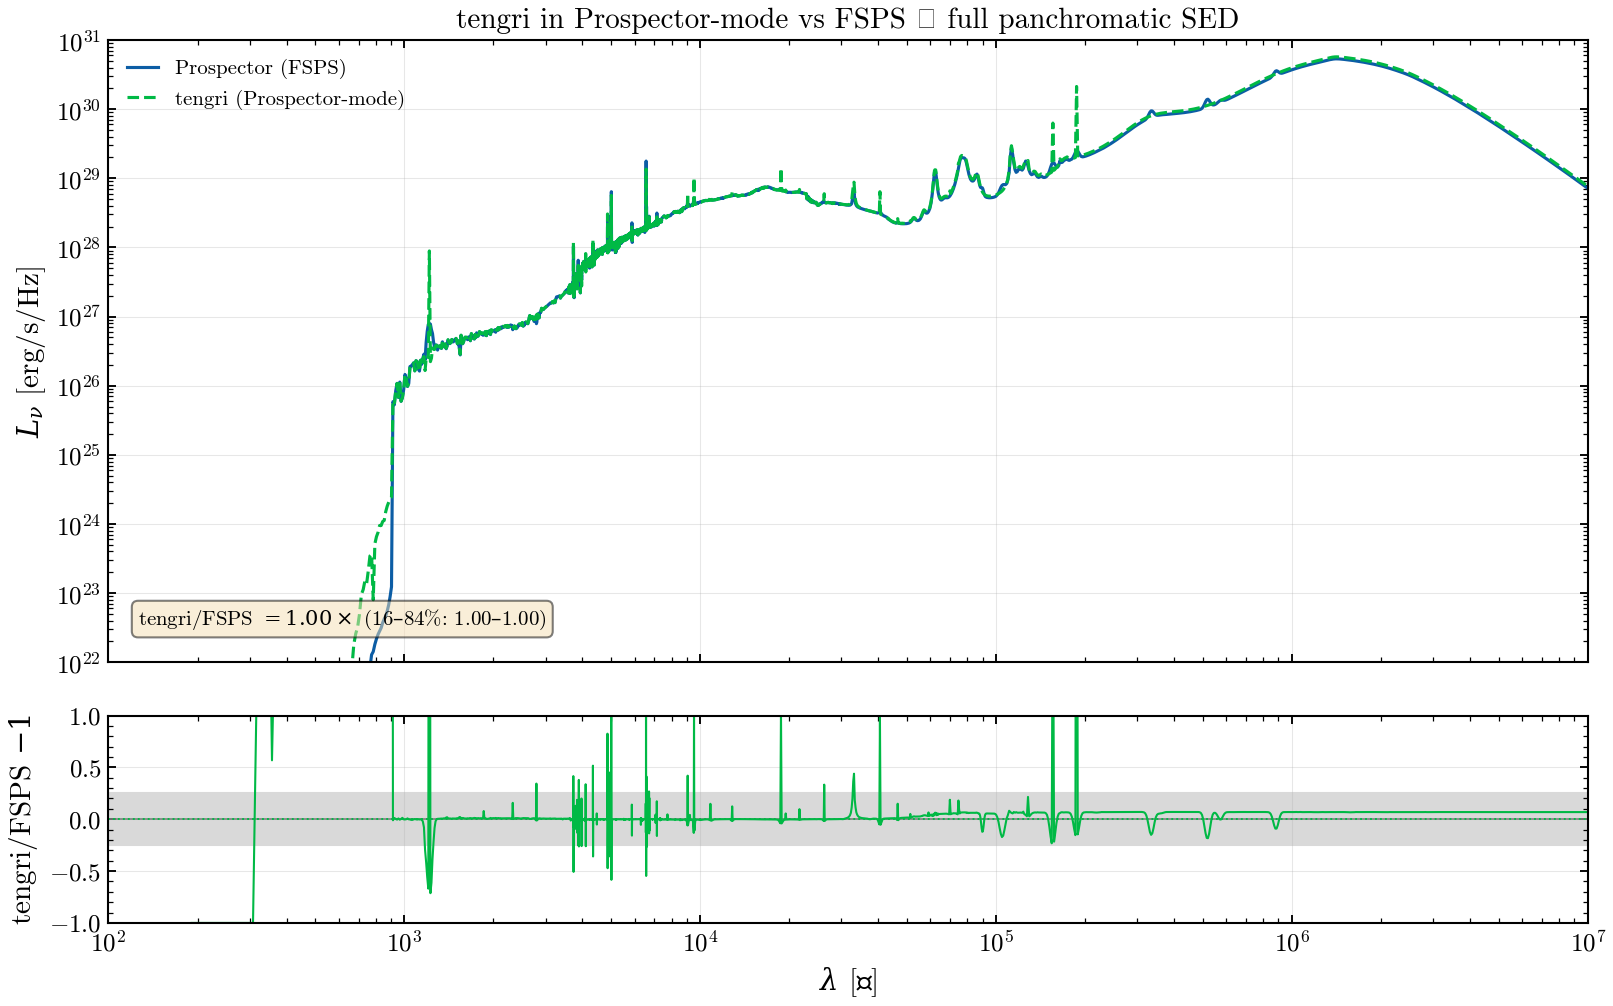

In [19]:
import chex

# Reuse the §7 panchromatic full SED: tengri's Prospector-mode model and
# FSPS's own output, both at the fiducial galaxy.
w_ext, L_ext = np.asarray(w_p_full), np.asarray(L_p_full)
wave_t = np.asarray(s_full.wave)
L_t = (
    np.asarray(s_full.derived["sed_dust_attenuated"])
    + np.asarray(s_full.derived["sed_dust_ir"])
    + np.asarray(s_full.derived["sed_nebular"])
)

# Put tengri on FSPS's wavelength grid so the two compare point for point.
L_t_on_ext = U.regrid(wave_t, L_t, w_ext)
chex.assert_equal_shape([L_ext, L_t_on_ext])

mask = (w_ext > 0) & (L_ext > 0) & (L_t_on_ext > 0)
resid = np.full(w_ext.shape, np.nan, dtype=float)
resid[mask] = L_t_on_ext[mask] / L_ext[mask] - 1.0

# Headline numbers: the optical normalization ratio tengri/FSPS and its
# robust 16–84% spread. With the §5 dust as a single screen matching FSPS
# `dust_type=2` (`dust1 = 0`), the spread sits at ≈ 1.01–1.01× — the
# *stellar continuum* matches FSPS to ~1%. The emission **lines are not in
# this band**: they are sparse points the 16–84 percentile rejects as
# outliers, and the residual panel shows them spiking to ±50–100 % — the
# Cue-vs-Byler+2017 line-strength difference (§8: Hα 0.88×, [O III] 0.81×,
# Hβ 0.95×) plus line center/width mismatches. So the tight spread is a
# clean continuum match, not evidence that the lines agree. Below 912 Å both
# codes absorb the stellar Lyman continuum at `neb_fesc = 0` (the gas
# reprocesses the ionizing photons into nebular emission), so the region
# falls to zero on both sides — tengri now applies the same fesc absorption
# on its two-component dust path (#825), matching FSPS.
opt = mask & (w_ext >= 1000.0) & (w_ext <= 10000.0)
ratio_opt = L_t_on_ext[opt] / L_ext[opt]
norm = float(np.median(ratio_opt))
p16, p84 = float(np.percentile(ratio_opt, 16)), float(np.percentile(ratio_opt, 84))
print(
    f"full-SED head-to-head tengri/FSPS optical (1000–10000 Å): "
    f"normalization {norm:.2f}×, 16–84% spread {p16:.2f}–{p84:.2f}×"
)
_assert_comparable(L_ext, L_t, name="full-SED head-to-head")

fig, (ax, ax_r) = plt.subplots(
    2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
ax.plot(w_ext, L_ext, "C0-", linewidth=1.5, label="Prospector (FSPS)")
ax.plot(w_ext, L_t_on_ext, "C1--", linewidth=1.5, label="tengri (Prospector-mode)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e2, 1e7)
ax.set_ylim(1e22, 1e31)
ax.set_ylabel(r"$L_\nu$ [erg/s/Hz]")
ax.set_title("tengri in Prospector-mode vs FSPS — full panchromatic SED")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.text(
    0.02,
    0.05,
    rf"tengri/FSPS $= {norm:.2f}\times$ (16–84%: {p16:.2f}–{p84:.2f})",
    transform=ax.transAxes,
    fontsize=10,
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

ax_r.axhspan(-0.25, 0.25, color="0.85", zorder=0)
ax_r.axhline(0.0, color="0.5", linewidth=0.8)
ax_r.axhline(norm - 1.0, color="C1", linestyle=":", linewidth=0.9)
ax_r.plot(w_ext, resid, "C1-", linewidth=1.0)
ax_r.set_xscale("log")
ax_r.set_xlim(1e2, 1e7)
ax_r.set_ylim(-1.0, 1.0)
ax_r.set_xlabel(r"$\lambda$ [Å]")
ax_r.set_ylabel(r"tengri/FSPS $-1$")
ax_r.grid(True, alpha=0.3)
fig.tight_layout()
save_fig("prospector_full_sed_headtohead.png")
plt.show()

## Summary

At matched parameters, FSPS-via-Prospector and tengri agree wherever they
evaluate the same mathematics: the SSP grid, the SFH shape, the attenuation
curves under the §5 single-screen mapping, the DL07 dust IR, and the Madau
IGM. They differ in the one place they use different physics inputs, the
nebular grid (Cue vs Byler+2017, §8). The per-section scalars printed above
are the quantitative record.

**Prospector-mode checklist.** Two *default conventions* differ between
the codes and must be set explicitly for a faithful match:

1. **Far-IR amplitude** — tengri's canonical energy balance excludes the
   Lyman continuum from dust heating, FSPS re-emits all of it;
   at this fiducial the difference is ~11 % in every FIR band. Opt into
   the FSPS convention with `dust={'eb_include_lyc': True}` (§6).
2. **IGM** — `SEDModel.build` defaults the IGM **on** (Inoue+2014);
   Prospector defaults `add_igm_absorption=False`. At z = 1 this alone
   moves a GALEX FUV band by ~18 % (rest-frame Lyman continuum). Match
   with `igm={'type': 'none'}` (or set FSPS's flag and use `'madau'`).

The nebular grid is not on that list: it is a physics-input difference
inherent to the backends, not a switchable convention.

**Verification Status:** PARTIAL (68/126) — Absolute SED normalization


## References

* Johnson, Leja, Conroy & Speagle 2021, ApJS 254, 22 — Prospector
* Leja et al. 2017, ApJ 837, 170 — Dirichlet non-parametric SFH
* Leja et al. 2019, ApJ 876, 3 — continuity & continuity-flex SFH priors
* Suess et al. 2022, ApJ 935, 146 — post-starburst non-parametric SFH
* Conroy, Gunn & White 2009, ApJ 699, 486 — FSPS
* Conroy & Gunn 2010, ApJ 712, 833 — FSPS calibration
* Choi et al. 2016, ApJ 823, 102 — MIST isochrones
* Sánchez-Blázquez et al. 2006, MNRAS 371, 703 — MILES library
* Chabrier 2003, PASP 115, 763 — IMF
* Calzetti et al. 2000, ApJ 533, 682 — starburst attenuation
* Charlot & Fall 2000, ApJ 539, 718 — two-component dust
* Kriek & Conroy 2013, ApJL 775, L16 — modified attenuation
* Draine & Li 2007, ApJ 657, 810 — dust IR emission
* Byler et al. 2017, ApJ 840, 44 — nebular grid
* Nenkova et al. 2008, ApJ 685, 160 — clumpy torus
* Madau 1995, ApJ 441, 18 — IGM absorption
* Li et al. 2025 — Cue nebular emulator